# Elemental sulfur in oil stabilization and gas recompression

**H₂S and O₂ · sulfur formation and deposition · liquid carryover · compressor degradation**

This executable engineering example adapts the three-stage separation concept and heavy
fractions in [comparesimulations2.ipynb](comparesimulations2.ipynb). It adds sour recovered
flare gas and a membrane nitrogen purge containing **1 mol% O₂** at the low-pressure gas
header, then follows the gas through recompression to 180 bara.

You will calculate four different quantities: the **reaction-equilibrium potential** for
making elemental sulfur, the **amount formed during finite residence time**, the **S₈
precipitated at local temperature and pressure**, and the **portion retained on walls or
filters**. A separate finite-inventory model demonstrates why rust and iron sulfide in a
pipe or filter cake can change the chemistry.

**Interpretation:** the process flashes and equipment are NeqSim calculations. The reaction
network, surface rates, residence times, and capture efficiencies are explicitly selected
screening assumptions. They are not calibrated deposition rates or a plant design basis.
All feed data are synthetic. Run all cells in a fresh Colab runtime; the first source build
can take several minutes. The saved notebook includes results from a clean execution.

Sections 10–13 add native separator entrainment, oil versus condensate entering a compressor, deposit accumulation, degraded performance and potential solutions. They distinguish equilibrium wet-compression effects from assumed fouling rates and from mechanical damage that this model does not calculate.

## 1. Install the bridge and load current NeqSim source

The default Colab path fetches `equinor/neqsim` **master** and builds its shaded Java JAR.
The Python distribution supplies the JPype bridge. A local validation run can supply an
already checked-out source tree and a source-built JAR, but still verifies the commit,
hashes, and actual Java class locations. Restart the runtime before selecting another JAR.

For the saved execution, Maven compiled current source successfully. The compiled
classes/resources were packaged into a thin JAR. This uses the local validation path
established after an earlier offline Maven archiver dependency failure. The released
3.20.0 JAR supplies third-party dependencies behind it on the classpath. The source-class
assertions below verify the actual calculation code.

In [1]:
import importlib.util
import importlib.metadata
import os
from pathlib import Path
import subprocess
import sys

requirements = ["neqsim==3.18.0", "numpy", "pandas", "matplotlib", "jpype1"]
missing = any(importlib.util.find_spec(name) is None
              for name in ["neqsim", "numpy", "pandas", "matplotlib", "jpype"])
if missing:
    install = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *requirements],
        text=True, capture_output=True,
    )
    if install.returncode:
        raise RuntimeError(install.stdout + install.stderr)
print("Python bridge:", importlib.metadata.version("neqsim"))
print("Python:", sys.version.split()[0])

Python bridge: 3.18.0
Python: 3.12.14


In [2]:
import hashlib
import json

NEQSIM_SOURCE_REF = "master"
SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-source"))
local_jar = os.environ.get("NEQSIM_SOURCE_JAR")


def command(arguments, directory=None):
    result = subprocess.run(arguments, cwd=directory, text=True, capture_output=True)
    if result.returncode:
        raise RuntimeError(result.stdout[-6000:] + result.stderr[-6000:])
    return result.stdout.strip()


if local_jar:
    source_jar = Path(local_jar).resolve()
    build_mode = os.environ.get("NEQSIM_BUILD_MODE", "Provided source-built JAR")
else:
    if not (source_root / ".git").exists():
        command(["git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
                 SOURCE_REPOSITORY, str(source_root)])
    else:
        command(["git", "fetch", "origin", NEQSIM_SOURCE_REF], source_root)
        command(["git", "checkout", "--detach", "FETCH_HEAD"], source_root)
    build = command(["bash", "./mvnw", "-DskipTests", "-Dmaven.test.skip=true",
                     "-Dcheckstyle.skip", "-Dspotbugs.skip", "-Dpmd.skip", "package"],
                    source_root)
    candidates = [p for p in (source_root / "target").glob("neqsim-*.jar")
                  if not any(word in p.name for word in ["sources", "javadoc", "tests"])]
    source_jar = max(candidates, key=lambda p: p.stat().st_size).resolve()
    build_mode = "Maven source compilation and shaded package"

source_commit = command(["git", "rev-parse", "HEAD"], source_root)
assert not command(["git", "diff", "--name-only", "HEAD", "--", "src/main"], source_root)
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
import jpype

assert not jpype.isJVMStarted(), "Restart this runtime before changing NeqSim JARs."
jpype.addClassPath(str(source_jar))
dependency_jar = os.environ.get("NEQSIM_DEPENDENCY_JAR")
if dependency_jar:
    jpype.addClassPath(str(Path(dependency_jar).resolve()))
jpype.startJVM("-Xmx2g")
from neqsim import jneqsim as neq

java_classes = [
    "neqsim.thermo.system.SystemSrkCPAstatoil",
    "neqsim.process.equipment.reactor.SulfurOxidationReactor",
    "neqsim.process.equipment.reactor.IronSulfideOxidationSource",
    "neqsim.process.equipment.separator.ThreePhaseSeparator",
    "neqsim.process.equipment.compressor.Compressor",
    "neqsim.process.equipment.compressor.CompressorDeposit",
    "neqsim.process.equipment.compressor.CompressorDepositWash",
]
origins = {}
for name in java_classes:
    location = jpype.JClass(name).class_.getProtectionDomain().getCodeSource().getLocation()
    loaded_path = Path(str(location.toURI().getPath())).resolve()
    assert loaded_path == source_jar, (name, loaded_path, source_jar)
    origins[name] = source_jar.name
provenance = {
    "source_repository": SOURCE_REPOSITORY, "requested_ref": NEQSIM_SOURCE_REF,
    "resolved_commit": source_commit, "source_jar_sha256": jar_sha256,
    "source_jar": source_jar.name, "build_mode": build_mode,
    "java_version": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python_bridge": importlib.metadata.version("neqsim"), "class_origins": origins,
}
if dependency_jar:
    provenance["dependency_container_sha256"] = hashlib.sha256(
        Path(dependency_jar).read_bytes()
    ).hexdigest()
print(json.dumps(provenance, indent=2))

{
  "source_repository": "https://github.com/equinor/neqsim.git",
  "requested_ref": "master",
  "resolved_commit": "b703de2fdce2bda4b4b212bb0b293984a552b092",
  "source_jar_sha256": "a3aea3865ff8cb4475a73643fc8c03f71c1c44cef874202274efd5b33d4db23b",
  "source_jar": "neqsim-3.20.0-source.jar",
  "build_mode": "Maven compiled current source; local thin JAR of target/classes; released JAR supplies third-party dependencies",
  "java_version": "17.0.20",
  "python_bridge": "3.18.0",
  "class_origins": {
    "neqsim.thermo.system.SystemSrkCPAstatoil": "neqsim-3.20.0-source.jar",
    "neqsim.process.equipment.reactor.SulfurOxidationReactor": "neqsim-3.20.0-source.jar",
    "neqsim.process.equipment.reactor.IronSulfideOxidationSource": "neqsim-3.20.0-source.jar",
    "neqsim.process.equipment.separator.ThreePhaseSeparator": "neqsim-3.20.0-source.jar",
    "neqsim.process.equipment.compressor.Compressor": "neqsim-3.20.0-source.jar",
    "neqsim.process.equipment.compressor.CompressorDeposit": 

## 2. Process boundary and input assumptions

Oil is stabilized at **33 / 9 / 1.7 bara**, at **70 / 68.2 / 65 °C**, then cooled to
40 °C and pumped to 60 bara. Gas is recompressed from 1.7 to 9, 33, 90, and 180 bara;
the MP and HP separator gases join their corresponding pressure headers. Compressor
isentropic efficiency is 75%. Pressures are absolute.

| Input | Selected value | Meaning |
|---|---:|---|
| Well feed | 100,000 kg/h | Reference light components and eight heavy cuts |
| H₂S addition | 0.5 mole parts | Replaces 0.5 methane parts before normalization |
| Water addition | 5 mole parts | Synthetic wet feed; not 5 mass% |
| Recovered flare gas | 500 kg/h | Sour methane-rich gas; composition is explicit below |
| Membrane purge | 200 Sm³/h | 99 mol% N₂ + 1 mol% O₂ |
| Standard volume basis | 15 °C, 1.01325 bar | Ideal-gas molar basis for reported Sm³ |
| Cooler/contact temperatures | 30–40 °C | Six specified downstream contact zones |
| Filters F-101 / F-102 | 95% of arriving solids | No dissolved-S₈ or O₂ removal |

The original notebook is a topology/composition reference, not a replicated plant case.
This example uses **SRK-CPA, mixing rule 10, PedersenSRK heavy-cut characterization** for
the wet fluid. All liquid drains leave the boundary; there is no condensate recycle.
The six contact zones include ideal liquid disengagement. Even the final export-line
control volume reports any equilibrium liquid as a separate phase outlet.

Oxygen enters the gas train **after oil separation**. Thus the direct H₂S/O₂ reaction
cannot occur upstream in this steady case. Rust can nevertheless produce sulfur upstream,
as section 8 demonstrates. Backflow, air ingress elsewhere, and oxygenated liquid recycle
would change that boundary.

In [3]:
import math
import numpy as np
import pandas as pd

R_GAS = 8.314462618
M_S = 0.032065
M_S8 = 8.0 * M_S
Stream = neq.process.equipment.stream.Stream
Ops = neq.thermodynamicoperations.ThermodynamicOperations


def component_rates(fluid):
    """Total component molar flows [mol/s], summed over physical phases."""
    return {
        str(fluid.getComponent(i).getComponentName()): sum(
            float(fluid.getPhase(p).getComponent(i).getNumberOfMolesInPhase())
            for p in range(fluid.getNumberOfPhases())
        )
        for i in range(fluid.getNumberOfComponents())
    }


def inventory_rates(fluid):
    return {
        str(fluid.getComponent(i).getComponentName()):
        float(fluid.getComponent(i).getNumberOfmoles())
        for i in range(fluid.getNumberOfComponents())
    }


def molrate(stream, name):
    return inventory_rates(stream.getThermoSystem()).get(name, 0.0)


def mass_rate(stream):
    return float(stream.getFlowRate("kg/hr"))


def fluid_with_rates(template, rates, temperature_c=None):
    """Rebuild totals explicitly; preserve EOS, components and TBP properties."""
    fluid = neq.thermo.system.SystemSrkCPAstatoil(
        float(template.getTemperature()), float(template.getPressure())
    )
    fluid.getCharacterization().setTBPModel("PedersenSRK")
    for name, amount in rates.items():
        assert amount >= -1e-12, (name, amount)
        amount = max(0.0, float(amount))
        component = template.getComponent(name) if template.hasComponent(name) else None
        if component is not None and component.isIsTBPfraction():
            fluid.addTBPfraction(
                name.removesuffix("_PC"), amount,
                float(component.getMolarMass()), float(component.getNormalLiquidDensity())
            )
        else:
            fluid.addComponent(name, amount)
    fluid.setMixingRule(10)
    if temperature_c is not None:
        fluid.setTemperature(float(temperature_c), "C")
    fluid.setMultiPhaseCheck(True)
    Ops(fluid).TPflash()
    fluid.initProperties()
    return fluid


def run_stream(name, fluid):
    stream = Stream(name, fluid)
    stream.run()
    return stream


def make_source(name, composition, mass_kg_h, temperature_c, pressure_bara):
    fluid = neq.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15, pressure_bara
    )
    for component, amount in composition.items():
        fluid.addComponent(component, float(amount))
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(mass_kg_h, "kg/hr")
    return run_stream(name, fluid)



from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 130, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.constrained_layout.use": True})

In [4]:
def build_stabilization():
    """Three separation stages; reference heavy cuts, synthetic H2S and water."""
    composition = {
        "CO2": 1.587, "methane": 52.01, "ethane": 6.24, "propane": 4.23,
        "i-butane": 0.855, "n-butane": 2.213, "i-pentane": 1.124,
        "n-pentane": 1.271, "n-hexane": 2.289, "H2S": 0.5, "water": 5.0,
    }
    cuts = [
        (0.8501, 108.47, 0.7411), (1.2802, 120.40, 0.7550),
        (1.6603, 133.64, 0.7695), (6.5311, 164.70, 0.7990),
        (6.3311, 215.94, 0.8387), (4.9618, 273.34, 0.8754),
        (2.9105, 334.92, 0.90731), (3.0505, 412.79, 0.94575),
    ]
    fluid = neq.thermo.system.SystemSrkCPAstatoil(343.15, 33.0)
    fluid.getCharacterization().setTBPModel("PedersenSRK")
    for name, amount in composition.items():
        fluid.addComponent(name, amount)
    for index, (amount, molecular_mass, density) in enumerate(cuts, start=1):
        fluid.addTBPfraction(
            f"C7+_cut{index}", amount, molecular_mass / 1000.0, density
        )
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(100000.0, "kg/hr")
    feed = run_stream("Sour well feed", fluid)
    oil = feed
    gases = []
    waters = []
    units = [feed]
    separators = []
    for index, (pressure, temperature) in enumerate(
        [(33.0, 70.0), (9.0, 68.2), (1.7, 65.0)], start=1
    ):
        if index > 1:
            valve = neq.process.equipment.valve.ThrottlingValve(
                f"Oil letdown {index}", oil
            )
            valve.setOutletPressure(pressure)
            valve.run()
            heater = neq.process.equipment.heatexchanger.Heater(
                f"Oil heater {index}", valve.getOutStream()
            )
            heater.setOutTemperature(temperature + 273.15)
            heater.run()
            units.extend([valve, heater])
            oil = heater.getOutStream()
        separator = neq.process.equipment.separator.ThreePhaseSeparator(
            f"20-VA-0{index}", oil
        )
        separator.run()
        gases.append(separator.getGasOutStream())
        waters.append(separator.getWaterOutStream())
        oil = separator.getOilOutStream()
        units.append(separator)
        separators.append(separator)
    oil_cooler = neq.process.equipment.heatexchanger.Cooler("21-HA-01", oil)
    oil_cooler.setOutTemperature(313.15)
    oil_cooler.run()
    oil_pump = neq.process.equipment.pump.Pump("21-PA-01", oil_cooler.getOutStream())
    oil_pump.setOutletPressure(60.0)
    oil_pump.run()
    oil_export = oil_pump.getOutStream()
    units.extend([oil_cooler, oil_pump])
    process = neq.process.processmodel.ProcessSystem()
    for unit in units:
        process.add(unit)
    return {
        "process": process, "feed": feed, "gas": gases, "water": waters,
        "oil": oil_export, "separators": separators, "units": units,
    }


def mix_streams(name, streams):
    mixer = neq.process.equipment.mixer.Mixer(name)
    for stream in streams:
        mixer.addStream(stream)
    mixer.run()
    return mixer.getOutStream(), mixer


def species_mass(rates, names, template):
    return sum(
        rates.get(name, 0.0) * float(template.getComponent(name).getMolarMass())
        for name in names if template.hasComponent(name)
    ) * 3600.0

In [5]:
base = build_stabilization()
separator_rows = []
for index, separator in enumerate(base["separators"], start=1):
    gas, oil, water = (separator.getGasOutStream(), separator.getOilOutStream(),
                       separator.getWaterOutStream())
    separator_rows.append({
        "Stage": index, "P (bara)": float(gas.getPressure("bara")),
        "T (C)": float(gas.getTemperature("C")), "Gas (kg/h)": mass_rate(gas),
        "Oil (kg/h)": mass_rate(oil), "Water (kg/h)": mass_rate(water),
        "H2S in gas (mol/s)": molrate(gas, "H2S"),
    })
display(pd.DataFrame(separator_rows).round(4))
oil_train_out = sum(mass_rate(s) for s in base["gas"] + base["water"] + [base["oil"]])
assert abs(oil_train_out - mass_rate(base["feed"])) < 0.01
print(f"Oil-section mass closure: {oil_train_out:,.6f} / {mass_rate(base['feed']):,.6f} kg/h")
print(
    f"Actual normalized feed H2S: "
    f"{100 * molrate(base['feed'], 'H2S') / base['feed'].getFlowRate('mol/sec'):.4f} mol%"
)

Oil-section mass closure: 100,000.000000 / 100,000.000000 kg/h
Actual normalized feed H2S: 0.4767 mol%


,Stage,P (bara),T (C),Gas (kg/h),Oil (kg/h),Water (kg/h),H2S in gas (mol/s)
0,1,33.0,70.0,14340.9699,84753.1580,905.8721,1.0842
1,2,9.0,68.2,1513.6799,83239.4781,0.0000,0.2054
2,3,1.7,65.0,1480.2721,81759.2060,0.0000,0.2316


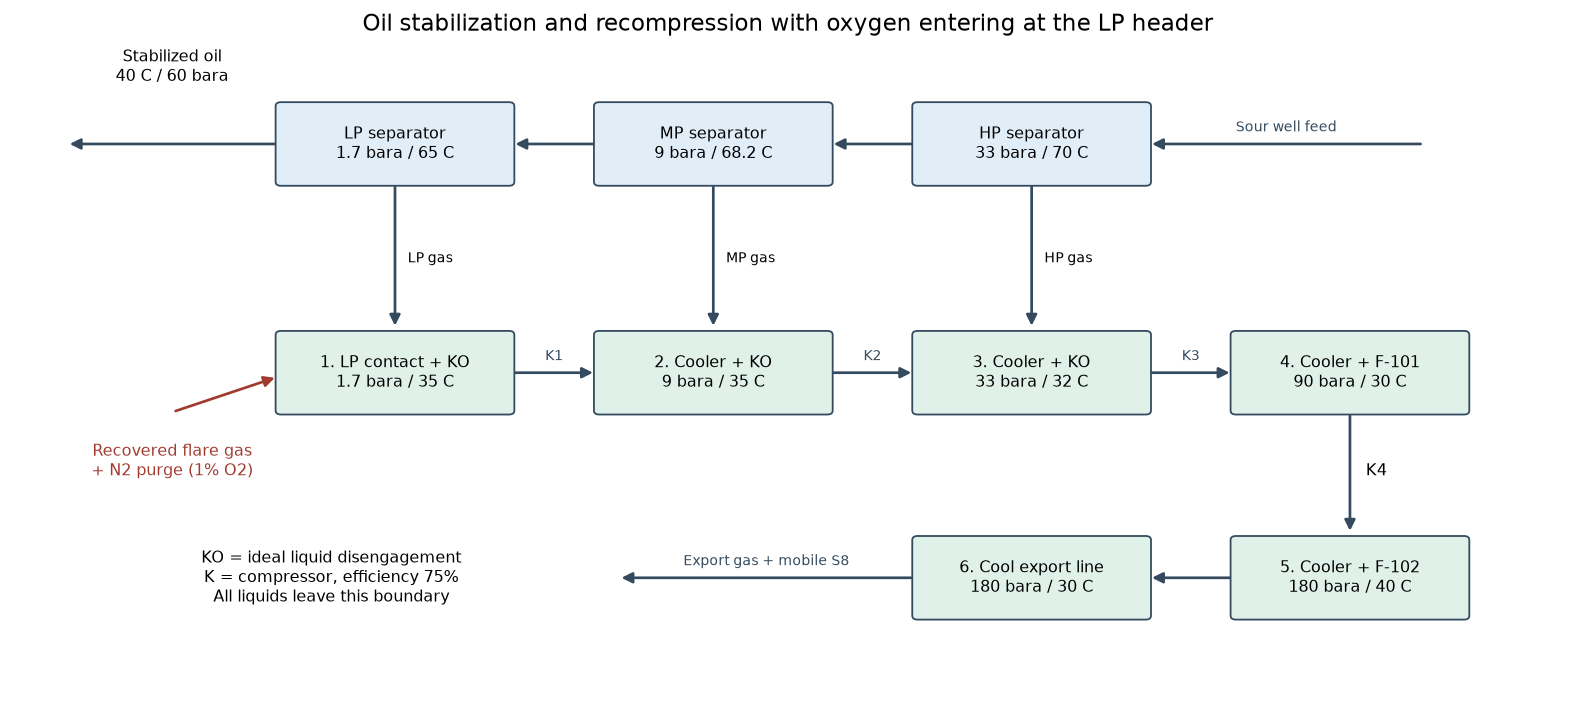

In [6]:
fig, ax = plt.subplots(figsize=(12, 5.4))
ax.set(xlim=(-1.6, 13.0), ylim=(-0.1, 8.2))
ax.axis("off")


def box(x, y, text, color="#e1edf7", width=2.15):
    patch = FancyBboxPatch((x - width / 2, y - 0.48), width, 0.96,
                          boxstyle="round,pad=0.05", fc=color, ec="#344b5f")
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=9)


def arrow(start, end, label=None, color="#344b5f"):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=12,
                                color=color, lw=1.5))
    if label:
        ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.16,
                label, ha="center", fontsize=8, color=color)


for x, label in [(8, "HP separator\n33 bara / 70 C"),
                 (5, "MP separator\n9 bara / 68.2 C"),
                 (2, "LP separator\n1.7 bara / 65 C")]:
    box(x, 7, label)
arrow((11.7, 7), (9.1, 7), "Sour well feed")
arrow((6.9, 7), (6.1, 7))
arrow((3.9, 7), (3.1, 7))
arrow((0.9, 7), (-1.1, 7))
ax.text(-0.1, 7.8, "Stabilized oil\n40 C / 60 bara", ha="center", fontsize=9)
for x, label in [(2, "LP gas"), (5, "MP gas"), (8, "HP gas")]:
    arrow((x, 6.5), (x, 4.65))
    ax.text(x + 0.12, 5.5, label, fontsize=8)
for x, label in [(2, "1. LP contact + KO\n1.7 bara / 35 C"),
                 (5, "2. Cooler + KO\n9 bara / 35 C"),
                 (8, "3. Cooler + KO\n33 bara / 32 C"),
                 (11, "4. Cooler + F-101\n90 bara / 30 C")]:
    box(x, 4.1, label, "#e0f1e9")
arrow((3.1, 4.1), (3.9, 4.1), "K1")
arrow((6.1, 4.1), (6.9, 4.1), "K2")
arrow((9.1, 4.1), (9.9, 4.1), "K3")
ax.text(-0.1, 2.8, "Recovered flare gas\n+ N2 purge (1% O2)",
        color="#a13b30", ha="center", fontsize=9)
arrow((-0.1, 3.6), (0.9, 4.05), color="#a13b30")
box(11, 1.5, "5. Cooler + F-102\n180 bara / 40 C", "#e0f1e9")
arrow((11, 3.6), (11, 2.05))
ax.text(11.15, 2.8, "K4", fontsize=9)
box(8, 1.5, "6. Cool export line\n180 bara / 30 C", "#e0f1e9")
arrow((9.9, 1.5), (9.1, 1.5))
arrow((6.9, 1.5), (4.1, 1.5), "Export gas + mobile S8")
ax.text(1.4, 1.5, "KO = ideal liquid disengagement\n"
        "K = compressor, efficiency 75%\nAll liquids leave this boundary",
        ha="center", va="center", fontsize=9)
fig.suptitle("Oil stabilization and recompression with oxygen entering at the LP header",
    fontsize=13)
plt.show()

## 3. Reaction equilibrium: a driving force and oxygen budget

The selected sulfur-forming reaction is

$$\mathrm{H_2S+\tfrac12 O_2\rightleftharpoons S(cond)+H_2O(g)}$$

NeqSim represents the elemental sulfur inventory as **S₈**: one mole of reacted H₂S creates
one-eighth mole of S₈. Rates reported as kg S/h are elemental sulfur mass, not kg H₂S/h.
For the reaction above, condensed sulfur has unit activity and the gas standard state is
1 bar. Using dimensionless fugacities $\hat f_i=f_i/(1\,\mathrm{bar})$:

$$K(T)=\exp[-\Delta_rG^\circ/(RT)]=\frac{\hat f_{H_2O}}{\hat f_{H_2S}\sqrt{\hat f_{O_2}}}$$

The calculation interpolates the embedded [NIST-JANAF](https://janaf.nist.gov/) formation
Gibbs energies between 298.15 and 600 K and uses the **local NeqSim gas fugacity
coefficients**, frozen during each reaction-equilibrium calculation. We solve in log
remaining O₂, avoiding subtraction underflow. This is a **restricted reaction-equilibrium
screen**, not a coupled gas/oil/water/ionic Gibbs minimization. It assumes a condensed
sulfur phase is accessible; section 5 separately tests precipitation at finite loading.

The independent stoichiometric ceiling is

$$\dot m_{S,\max}=M_S\min(\dot n_{H_2S},2\dot n_{O_2})$$

The selective pathway is not the only favorable chemistry. Full oxidation,
$\mathrm{H_2S+1.5O_2\rightarrow SO_2+H_2O}$, can compete; aqueous sulfide, polysulfides,
thiosulfate and sulfate are excluded. If SO₂ is present, the balanced Claus reaction is
$\mathrm{2H_2S+SO_2\rightarrow3S+2H_2O}$. No SO₂ is fed here, and this notebook does not
predict selectivity by minimizing over all these products.

In [7]:
# JANAF formation Gibbs energies [kJ/mol], standard state 1 bar.
JANAF_T = np.array([298.15, 300.0, 400.0, 500.0, 600.0])
JANAF_G_H2S = np.array([-33.329, -33.408, -37.343, -40.179, -42.399])
JANAF_G_WATER = np.array([-228.582, -228.500, -223.901, -219.051, -214.007])
JANAF_G_SO2 = np.array([-300.125, -300.145, -300.971, -300.871, -300.305])


def reaction_thermodynamics(temperature_k):
    assert JANAF_T[0] <= temperature_k <= JANAF_T[-1]
    h2s = np.interp(temperature_k, JANAF_T, JANAF_G_H2S)
    water = np.interp(temperature_k, JANAF_T, JANAF_G_WATER)
    so2 = np.interp(temperature_k, JANAF_T, JANAF_G_SO2)
    selective_g = (water - h2s) * 1000.0
    full_g = (so2 + water - h2s) * 1000.0
    return selective_g, -selective_g / (R_GAS * temperature_k), full_g


def restricted_equilibrium(stream):
    """Solve R1 in log residual O2 with frozen local gas fugacity coefficients."""
    fluid = stream.getThermoSystem()
    gas = fluid.getPhase("gas")
    temperature = float(fluid.getTemperature())
    pressure = float(fluid.getPressure("bara"))
    h2s = float(gas.getComponent("H2S").getNumberOfMolesInPhase())
    oxygen = float(gas.getComponent("oxygen").getNumberOfMolesInPhase())
    water = float(gas.getComponent("water").getNumberOfMolesInPhase())
    inert = float(gas.getNumberOfMolesInPhase()) - h2s - oxygen - water
    delta_g, log_k, full_g = reaction_thermodynamics(temperature)
    if oxygen <= 0.0:
        return {"equilibrium_S_kg_h": 0.0, "log10_O2_remaining_fraction": np.nan,
                "log10_K_R1": log_k / math.log(10), "residual": 0.0}
    assert h2s > 2.0 * oxygen, "This logarithmic solver requires excess H2S."
    phi = {
        name: float(gas.getComponent(name).getFugacityCoefficient())
        for name in ["H2S", "oxygen", "water"]
    }

    def residual(log_fraction):
        oxygen_left = oxygen * math.exp(log_fraction)
        extent = 2.0 * (oxygen - oxygen_left)
        h2s_left = h2s - extent
        water_out = water + extent
        total = inert + h2s_left + water_out + oxygen_left
        log_f_water = math.log(phi["water"] * water_out / total * pressure)
        log_f_h2s = math.log(phi["H2S"] * h2s_left / total * pressure)
        log_f_o2 = math.log(phi["oxygen"] * oxygen / total * pressure) + log_fraction
        return log_f_water - log_f_h2s - 0.5 * log_f_o2 - log_k

    lower, upper = -700.0, 0.0
    assert residual(lower) > 0.0 > residual(upper)
    for _ in range(100):
        middle = 0.5 * (lower + upper)
        if residual(middle) > 0:
            lower = middle
        else:
            upper = middle
    root = 0.5 * (lower + upper)
    return {
        "equilibrium_S_kg_h": 2.0 * oxygen * (-math.expm1(root)) * M_S * 3600.0,
        "log10_O2_remaining_fraction": root / math.log(10),
        "log10_K_R1": log_k / math.log(10), "residual": abs(residual(root)),
    }

In [8]:
thermo_rows = []
for temperature_c in [25.0, 35.0, 70.0, 150.0]:
    delta_g, log_k, full_g = reaction_thermodynamics(temperature_c + 273.15)
    thermo_rows.append({"T (C)": temperature_c, "R1 dG0 (kJ/mol H2S)": delta_g / 1000,
                        "log10 K(R1)": log_k / math.log(10),
                        "Full oxidation dG0 (kJ/mol H2S)": full_g / 1000})
display(pd.DataFrame(thermo_rows).round(3))
oxygen_input_mol_s = 200.0 * 101325.0 / (R_GAS * 288.15) / 3600.0 * 0.01
oxygen_sulfur_ceiling = 2.0 * oxygen_input_mol_s * M_S * 3600.0
print(f"O2 input: {oxygen_input_mol_s:.8f} mol/s; sulfur ceiling: {oxygen_sulfur_ceiling:.4f} kg/h")
assert np.isclose(reaction_thermodynamics(298.15)[0] / 1000.0, -195.253)
# Columns: H2S, O2, H2O, S8. Rows: hydrogen, oxygen, sulfur atoms.
atoms = np.array([[2, 0, 2, 0], [0, 2, 1, 0], [1, 0, 0, 8]])
stoichiometry = np.array([-1.0, -0.5, 1.0, 0.125])
assert np.allclose(atoms @ stoichiometry, 0.0)
print("Independent reaction stoichiometry and 298.15 K JANAF check passed.")

O2 input: 0.02349586 mol/s; sulfur ceiling: 5.4244 kg/h
Independent reaction stoichiometry and 298.15 K JANAF check passed.


,T (C),R1 dG0 (kJ/mol H2S),log10 K(R1),Full oxidation dG0 (kJ/mol H2S)
0,25.0,-195.253,34.207,-495.378
1,35.0,-194.396,32.952,-494.609
2,70.0,-191.410,29.136,-491.911
3,150.0,-184.779,22.809,-485.727


## 4. Finite-rate chemistry and phase-aware deposition

For an oxygen-limited gas stream contacting a reactive surface, use a plug-flow
residence approximation with pseudo-first-order O₂ disappearance:

$$X_{O_2}=1-\exp[-(k_g+k_s)\tau],\qquad k_s=v_s(T)\frac{A}{V}F_mF_u$$

$$v_s(T)=v_{s,ref}\exp\left[-\frac{E_s}{R}\left(\frac1T-\frac1{T_{ref}}\right)\right]$$

| Parameter | Value | Status |
|---|---:|---|
| Surface velocity at 50 °C | 0.001 m/s | Illustrative; not a measured pipe constant |
| Surface activation energy | 40 kJ/mol | Illustrative sensitivity value |
| Material/exposure factor $F_m$ | 1 baseline; 0.03 and 3 sensitivities | Not universal alloy properties |
| Uncertainty factor $F_u$ | 1 baseline | Can be varied independently |
| Gas-phase Arrhenius prefactor | $10^{10}$ s⁻¹ | Indicative NeqSim analyser parameter |
| Gas-phase activation energy | 160 kJ/mol | Unqualified homogeneous screening model |
| Contact $A/V$ | 8–12 m⁻¹ | Selected exposed area per gas volume |
| Residence time | 20–600 s | Selected; not inferred from equipment dimensions |

These parameters isolate the consequences of uncertain kinetics. They do not establish a
reaction-rate correlation for a specific steel, alloy, wet film, or filter medium. The
NeqSim reactor performs the bounded stoichiometric change; Python supplies the conversion
from the explicit rate law. The baseline assumes complete selectivity to S₈.

At each cold contact zone we then run the component-selected S₈ solid flash. Vapor and
liquid phases retain their equilibrium S₈. Available solids are split explicitly:

$$\dot m_{wall}=r\dot m_{solid},\quad\dot m_{filter}=\eta(1-r)\dot m_{solid},\quad\dot m_{mobile}=(1-\eta)(1-r)\dot m_{solid}$$

The wall-retention fractions $r$ (5–25%) and filter efficiency $\eta$ are input assumptions,
not results of the equilibrium flash. Solid carryover is a separate conserved particle
payload that is recombined for the next cold flash. Particles may redissolve there. The
hot compressor transit has no particle/phase re-equilibration or assumed wall capture;
its homogeneous-gas residence-time screen is reported separately. Hot reactive surfaces,
local metal temperature, erosion, particle size, wetting and heterogeneous nucleation
require additional data. Sulfur already dissolved in condensate is not counted as a
deposit, but could precipitate later if that liquid cools or flashes elsewhere.

Each reaction is held at specified temperature; the reported reaction heat uses the
298 K gas-water enthalpy change of 221.324 kJ per mole H₂S. This is an approximate heat
removal screen, separate from native cooler duties; no adiabatic reaction temperature or
hot-spot prediction is claimed. Sulfur melts near 115.2 °C, so condensed sulfur in a hot
machine is not necessarily solid. All six deposition zones here are below that temperature.

In [9]:
def contact_zone(stream, particles_mol_s, tag, temperature_c, residence_s,
                 area_to_volume, surface_factor, rate_multiplier, capture_fraction,
                 filter_efficiency=0.0):
    """React, flash, partition, and conserve sulfur across one contact/drum zone."""
    inlet_rates = inventory_rates(stream.getThermoSystem())
    inlet_rates["S8"] = inlet_rates.get("S8", 0.0) + particles_mol_s
    inlet_fluid = fluid_with_rates(stream.getThermoSystem(), inlet_rates, temperature_c)
    inlet = run_stream(tag + " contact inlet", inlet_fluid)
    h2s = molrate(inlet, "H2S")
    oxygen = molrate(inlet, "oxygen")
    temperature_k = temperature_c + 273.15
    # k_surface,ref = 0.001 m/s at 50 C: scenario value, not a fitted material constant.
    surface_velocity = 0.001 * math.exp(
        -40000.0 / R_GAS * (1.0 / temperature_k - 1.0 / 323.15)
    )
    k_surface = surface_velocity * area_to_volume * surface_factor * rate_multiplier
    # Existing NeqSim analyser's indicative homogeneous Arrhenius set, unqualified here.
    k_gas = 1.0e10 * math.exp(-160000.0 / (R_GAS * temperature_k))
    oxygen_fraction = -math.expm1(-(k_surface + k_gas) * residence_s)
    extent_h2s = min(h2s, 2.0 * oxygen * oxygen_fraction)
    reactor = neq.process.equipment.reactor.SulfurOxidationReactor(tag + " chemistry", inlet)
    reactor.setH2SConversionTarget(extent_h2s / h2s if h2s > 0.0 else 0.0)
    reactor.setSolidFlashEnabled(False)
    reactor.run()
    reacted = reactor.getOutStream()
    expected = dict(inlet_rates)
    expected["H2S"] = h2s - extent_h2s
    expected["oxygen"] = oxygen - extent_h2s / 2.0
    expected["water"] = expected.get("water", 0.0) + extent_h2s
    expected["S8"] = expected.get("S8", 0.0) + extent_h2s / 8.0
    actual = inventory_rates(reacted.getThermoSystem())
    reaction_error = max(abs(actual.get(k, 0.0) - v) for k, v in expected.items())
    assert reaction_error < 1e-7, (tag, reaction_error)
    # A new inventory avoids subtracting bulk moles from a nearly depleted gas phase.
    solid_fluid = fluid_with_rates(reacted.getThermoSystem(), expected)
    solid_fluid.setSolidPhaseCheck("S8")
    Ops(solid_fluid).TPflash()
    solid_fluid.initProperties()
    phase_sum = component_rates(solid_fluid)
    phase_error = max(abs(phase_sum.get(k, 0.0) - v) for k, v in expected.items())
    assert all(np.isclose(phase_sum.get(k, 0.0), v, rtol=1e-4, atol=1e-8)
               for k, v in expected.items()), (
        tag, "phase inventory", [(k, v, phase_sum.get(k)) for k, v in expected.items()
                                 if not np.isclose(phase_sum.get(k, 0.0), v,
                                                   rtol=1e-4, atol=1e-8)]
    )
    solid_s8 = 0.0
    liquids = []
    for phase_index in range(solid_fluid.getNumberOfPhases()):
        phase = solid_fluid.getPhase(phase_index)
        phase_name = str(phase.getType()).lower()
        if phase_name == "solid":
            solid_s8 += float(phase.getComponent("S8").getNumberOfMolesInPhase())
        elif phase_name != "gas":
            phase_fluid = solid_fluid.phaseToSystem(phase_index)
            liquids.append(Stream(tag + " " + phase_name + " drain", phase_fluid))
    gas_phase = solid_fluid.getPhase("gas")
    gas_rates = {
        name: float(gas_phase.getComponent(name).getNumberOfMolesInPhase())
        for name in expected
    }
    gas_fluid = fluid_with_rates(solid_fluid, gas_rates)
    outlet = Stream(tag + " gas outlet", gas_fluid)
    wall_capture = solid_s8 * capture_fraction
    filter_capture = (solid_s8 - wall_capture) * filter_efficiency
    transported = solid_s8 - wall_capture - filter_capture
    liquid_sulfur = sum(molrate(liquid, "S8") for liquid in liquids)
    row = {
        "Location": tag, "T_C": temperature_c,
        "P_bara": float(inlet.getPressure("bara")), "residence_s": residence_s,
        "k_surface_s-1": k_surface, "k_gas_s-1": k_gas,
        "O2_in_mol_s": oxygen, "O2_out_mol_s": molrate(outlet, "oxygen"),
        "O2_reacted_mol_s": extent_h2s / 2.0,
        "formed_S_kg_h": extent_h2s * M_S * 3600.0,
        "solid_available_kg_h": solid_s8 * M_S8 * 3600.0,
        "wall_deposit_kg_h": wall_capture * M_S8 * 3600.0,
        "filter_capture_kg_h": filter_capture * M_S8 * 3600.0,
        "liquid_S_kg_h": liquid_sulfur * M_S8 * 3600.0,
        "mobile_S_kg_h": transported * M_S8 * 3600.0,
        "gas_S_kg_h": molrate(outlet, "S8") * M_S8 * 3600.0,
        "isothermal_heat_removed_kW": extent_h2s * 221.324,
        "reaction_molar_error": reaction_error, "phase_molar_error": phase_error,
    }
    return outlet, transported, liquids, row, reactor

Fresh SRK-CPA systems are rebuilt from the component inventories between reactive contact
zones, preserving the heavy-cut inputs. This avoids carrying active solid-phase handles
into the next reactor. The selected `setSolidPhaseCheck("S8")` + `TPflash()` route is used;
the broader `TPSolidflash()` route was nonconservative for TBP solids in the test case.
Per-component phase closure is required within 0.01% relative plus $10^{-8}$ mol/s absolute;
the complete process balance below is checked more tightly.

In [10]:
def run_recompression(stabilization, surface_factor=1.0, rate_multiplier=1.0,
                      nitrogen_sm3_h=200.0, oxygen_fraction=0.01,
                      filter_efficiency=0.95):
    """Fresh forward solve. All liquid drains leave the case; no hidden recycle."""
    flare = make_source("Recovered sour flare gas", {
        "methane": 0.94, "ethane": 0.028, "CO2": 0.03,
        "H2S": 0.002, "water": 0.001,
    }, 500.0, 35.0, 1.7)
    purge = make_source("Membrane nitrogen purge", {
        "nitrogen": 1.0 - oxygen_fraction, "oxygen": oxygen_fraction,
        "water": 0.0, "H2S": 0.0,
    }, 1.0, 35.0, 1.7)
    purge_mol_s = nitrogen_sm3_h * 101325.0 / (R_GAS * 288.15) / 3600.0
    purge.setFlowRate(purge_mol_s, "mol/sec")
    purge.run()
    stream, mixer = mix_streams("FGR / LP gas header", [stabilization["gas"][2], flare, purge])
    header = stream.clone()
    units = [flare, purge, mixer]
    liquids = []
    rows = []
    particles = 0.0
    named = {"FGR mixed header": header}
    # Areas/volumes, residence times, and retention efficiencies are scenario inputs.
    zones = [
        ("FGR header and LP scrubber", 35.0, 60.0, 12.0, 0.05, 0.0),
        ("LP discharge cooler / MP scrubber", 35.0, 45.0, 8.0, 0.08, 0.0),
        ("MP discharge cooler / HP scrubber", 32.0, 40.0, 8.0, 0.10, 0.0),
        ("90 bar aftercooler / filter F-101", 30.0, 30.0, 10.0, 0.05, filter_efficiency),
        ("180 bar aftercooler / filter F-102", 40.0, 20.0, 8.0, 0.05, filter_efficiency),
        ("Cool export line", 30.0, 600.0, 8.0, 0.25, 0.0),
    ]
    pressures = [9.0, 33.0, 90.0, 180.0]
    compressors = []
    coolers = []
    for index, (tag, temp, residence, area_ratio, retention, efficiency) in enumerate(zones):
        cooler = neq.process.equipment.heatexchanger.Cooler(tag + " cooling", stream)
        cooler.setOutTemperature(temp + 273.15)
        cooler.run()
        stream = cooler.getOutStream()
        coolers.append(cooler)
        units.append(cooler)
        named[tag + " before reaction"] = stream.clone()
        stream, particles, drains, row, reactor = contact_zone(
            stream, particles, tag, temp, residence, area_ratio,
            surface_factor, rate_multiplier, retention, efficiency,
        )
        units.append(reactor)
        liquids.extend(drains)
        rows.append(row)
        named[tag] = stream.clone()
        if index < len(pressures):
            compressor = neq.process.equipment.compressor.Compressor(
                f"Gas compressor {index + 1}", stream
            )
            compressor.setOutletPressure(pressures[index])
            compressor.setIsentropicEfficiency(0.75)
            compressor.run()
            stream = compressor.getOutStream()
            compressors.append(compressor)
            units.append(compressor)
            named[f"Compressor {index + 1} discharge"] = stream.clone()
            if index in [0, 1]:
                added_gas = stabilization["gas"][1 - index]
                stream, mixer = mix_streams(
                    f"Gas interstage mixer {index + 1}", [stream, added_gas]
                )
                units.append(mixer)
    return {
        "rows": pd.DataFrame(rows), "gas": stream, "particles_mol_s": particles,
        "liquid": liquids, "flare": flare, "purge": purge, "header": header,
        "compressors": compressors, "coolers": coolers, "units": units, "named": named,
    }


def case_balance(stabilization, case):
    inlets = [stabilization["feed"], case["flare"], case["purge"]]
    outlets = [stabilization["oil"], case["gas"]] + stabilization["water"] + case["liquid"]
    deposited = case["rows"]["wall_deposit_kg_h"].sum()
    captured = case["rows"]["filter_capture_kg_h"].sum()
    mobile = case["particles_mol_s"] * M_S8 * 3600.0
    mass_in = sum(mass_rate(s) for s in inlets)
    mass_out = sum(mass_rate(s) for s in outlets) + deposited + captured + mobile
    sulfur_in = sum((molrate(s, "H2S") + 8.0 * molrate(s, "S8")) * M_S * 3600.0 for s in inlets)
    sulfur_out = sum((molrate(s, "H2S") + 8.0 * molrate(s, "S8")) * M_S * 3600.0 for s in outlets)
    sulfur_out += deposited + captured + mobile
    oxygen_in = sum(molrate(s, "oxygen") for s in inlets)
    oxygen_out = sum(molrate(s, "oxygen") for s in outlets)
    oxygen_reacted = case["rows"]["O2_reacted_mol_s"].sum()
    return {
        "mass_in_kg_h": mass_in, "mass_out_kg_h": mass_out,
        "relative_mass_error": abs(mass_out - mass_in) / mass_in,
        "S_in_kg_h": sulfur_in, "S_out_kg_h": sulfur_out,
        "relative_S_error": abs(sulfur_out - sulfur_in) / sulfur_in,
        "O2_mol_s_error": abs(oxygen_in - oxygen_out - oxygen_reacted),
        "S_formed_kg_h": case["rows"]["formed_S_kg_h"].sum(),
        "S_wall_kg_h": deposited, "S_filters_kg_h": captured,
        "S_mobile_export_kg_h": mobile,
    }

## 5. Run the complete case and locate sulfur

The table distinguishes sulfur made **in this zone** from the solid inventory arriving at
its retention step. That inventory can include particles from earlier zones, so it must
not be summed across stages as if every row represented newly created sulfur.

In [11]:
case = run_recompression(base)
rows = case["rows"]
conditions = rows[["Location", "T_C", "P_bara", "residence_s", "k_surface_s-1"]].copy()
display(conditions.round(6))
fates = rows[["Location", "formed_S_kg_h", "solid_available_kg_h", "wall_deposit_kg_h",
             "filter_capture_kg_h", "liquid_S_kg_h", "mobile_S_kg_h", "gas_S_kg_h"]].copy()
fates.columns = ["Location", "Formed", "Solid available", "Wall", "Filter", "Liquid",
                 "Mobile solid", "Gas S8"]
display(Markdown(
    "**Sulfur rates below are kg S/h.** Liquid is a drain; mobile solid and gas S8 continue."
))
display(fates.round(5))

,Location,T_C,P_bara,residence_s,k_surface_s-1
0,FGR header and LP scrubber,35.0,1.7,60.0,0.005814
1,LP discharge cooler / MP scrubber,35.0,9.0,45.0,0.003876
2,MP discharge cooler / HP scrubber,32.0,33.0,40.0,0.003324
3,90 bar aftercooler / filter F-101,30.0,90.0,30.0,0.003745
4,180 bar aftercooler / filter F-102,40.0,180.0,20.0,0.004973
5,Cool export line,30.0,180.0,600.0,0.002996


**Sulfur rates below are kg S/h.** Liquid is a drain; mobile solid and gas S8 continue.

,Location,Formed,Solid available,Wall,Filter,Liquid,Mobile solid,Gas S8
0,FGR header and LP scrubber,1.59740,1.58802,0.07940,0.00000,0.00911,1.50862,0.00026
1,LP discharge cooler / MP scrubber,0.61251,1.86743,0.14939,0.00000,0.25383,1.71803,0.00014
2,MP discharge cooler / HP scrubber,0.40019,1.60545,0.16054,0.00000,0.51244,1.44490,0.00050
3,90 bar aftercooler / filter F-101,0.29895,1.74039,0.08702,1.57071,0.00000,0.08267,0.00396
4,180 bar aftercooler / filter F-102,0.23803,0.15670,0.00784,0.14143,0.00000,0.00744,0.16796
5,Cool export line,1.89902,1.95353,0.48838,0.00000,0.00000,1.46515,0.12089


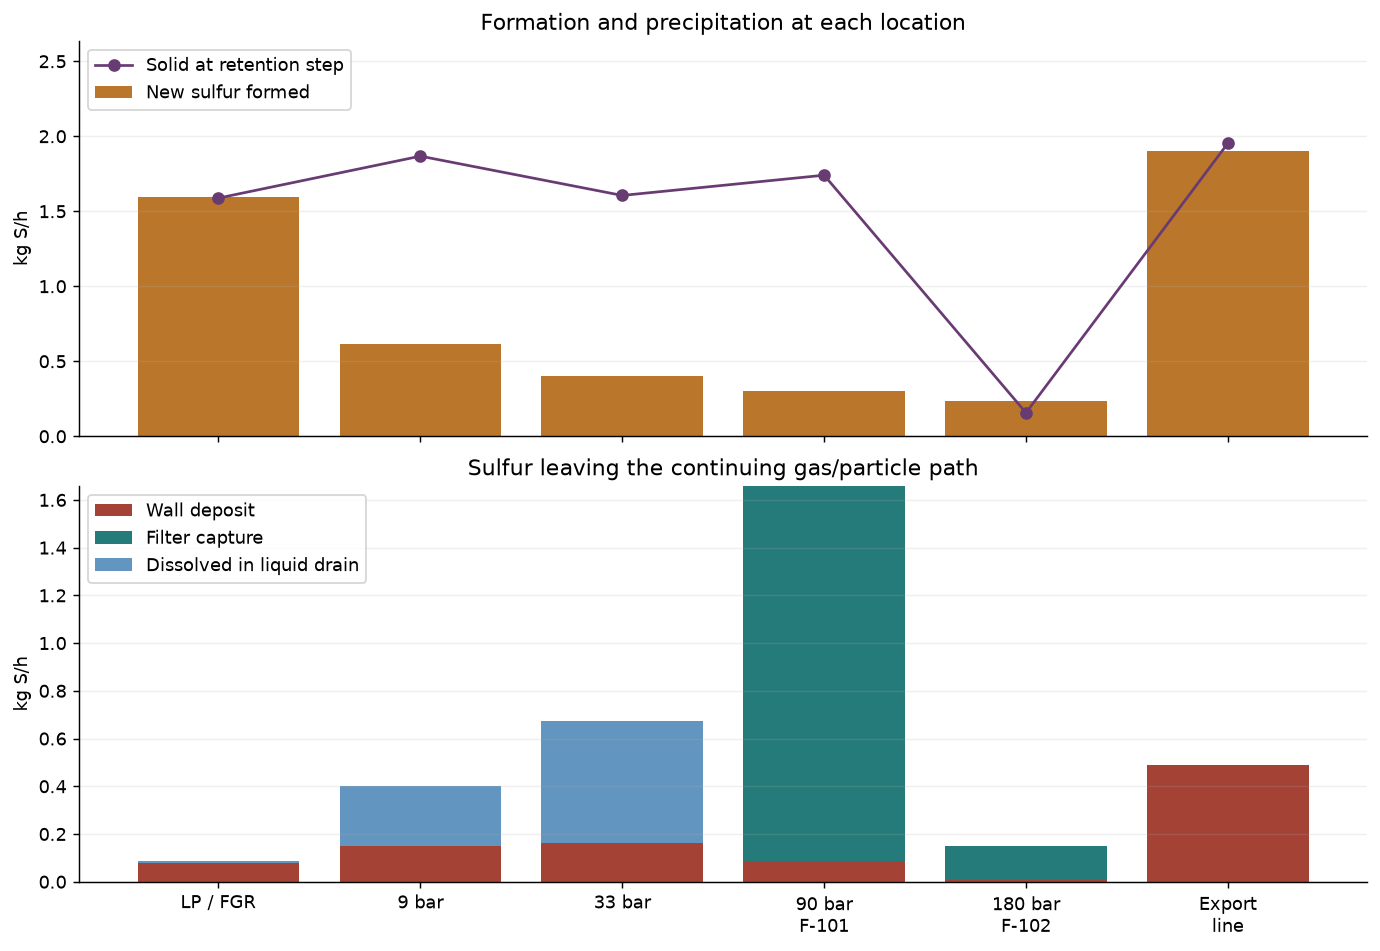

In [12]:
zone_labels = ["LP / FGR", "9 bar", "33 bar", "90 bar\nF-101", "180 bar\nF-102", "Export\nline"]
x = np.arange(len(rows))
fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), sharex=True)
axes[0].bar(x, rows["formed_S_kg_h"], color="#ba762b", label="New sulfur formed")
axes[0].plot(x, rows["solid_available_kg_h"], "o-",
    color="#683b73", label="Solid at retention step")
axes[0].set(ylabel="kg S/h", title="Formation and precipitation at each location")
axes[0].legend(loc="upper left")
peak_sulfur = max(rows["formed_S_kg_h"].max(), rows["solid_available_kg_h"].max())
axes[0].set_ylim(0, peak_sulfur * 1.35)
bottom = np.zeros(len(rows))
for name, label, color in [("wall_deposit_kg_h", "Wall deposit", "#a34235"),
                            ("filter_capture_kg_h", "Filter capture", "#247b79"),
                            ("liquid_S_kg_h", "Dissolved in liquid drain", "#6295bf")]:
    axes[1].bar(x, rows[name], bottom=bottom, label=label, color=color)
    bottom += rows[name].to_numpy()
axes[1].set(xticks=x, xticklabels=zone_labels, ylabel="kg S/h",
            title="Sulfur leaving the continuing gas/particle path")
axes[1].legend(loc="upper left")
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
plt.show()

## 6. Equilibrium versus kinetics, equipment conditions, and conservation

Each equilibrium result below is the **additional sulfur potential from the O₂ still
present locally**, starting from the finite-rate upstream solution. These local potentials
must not be added: they repeatedly refer to the same diminishing oxygen supply. The very
small equilibrium O₂ fraction is a logarithmic thermodynamic result, not a measurable
concentration prediction at a real instrument.

In [13]:
equilibrium_rows = []
for location in rows["Location"]:
    equilibrium = restricted_equilibrium(case["named"][location + " before reaction"])
    equilibrium_rows.append({"Location": location, **equilibrium})
equilibrium_table = pd.DataFrame(equilibrium_rows)
assert equilibrium_table["residual"].max() < 1e-10
display(equilibrium_table.drop(columns="residual").round(4))

compressor_rows = []
for index, compressor in enumerate(case["compressors"], start=1):
    outlet = compressor.getOutStream()
    temp_k = float(outlet.getTemperature())
    homogeneous_k = 1e10 * math.exp(-160000.0 / (R_GAS * temp_k))
    compressor_rows.append({
        "Compressor": index, "Discharge (bara)": float(outlet.getPressure("bara")),
        "Discharge (C)": temp_k - 273.15,
        "Power (kW)": float(compressor.getPower("kW")),
        "Gas-only O2 conversion in 0.5 s": -math.expm1(-homogeneous_k * 0.5),
    })
compressor_table = pd.DataFrame(compressor_rows)
conversion_column = "Gas-only O2 conversion in 0.5 s"
compressor_table[conversion_column] = compressor_table[conversion_column].map(
    lambda value: f"{value:.2e}"
)
display(compressor_table.round(3))
print("Homogeneous hot-transit calculation uses the indicative gas rate only; "
      "reactive metal is excluded.")

Homogeneous hot-transit calculation uses the indicative gas rate only; reactive metal is excluded.


,Location,equilibrium_S_kg_h,log10_O2_remaining_fraction,log10_K_R1
0,FGR header and LP scrubber,5.4244,-63.0136,32.9516
1,LP discharge cooler / MP scrubber,3.8265,-63.8620,32.9516
2,MP discharge cooler / HP scrubber,3.2133,-65.0179,33.3194
3,90 bar aftercooler / filter F-101,2.8132,-66.4710,33.5686
4,180 bar aftercooler / filter F-102,2.5142,-64.0840,32.3543
5,Cool export line,2.2762,-66.8025,33.5686


,Compressor,Discharge (bara),Discharge (C),Power (kW),Gas-only O2 conversion in 0.5 s
0,1,9.0,147.341,131.107,6.66e-11
1,2,33.0,122.606,169.775,3.81e-12
2,3,90.0,118.944,784.905,2.42e-12
3,4,180.0,85.439,458.870,2.47e-14


In [14]:
balance = case_balance(base, case)
assert balance["relative_mass_error"] < 1e-6
assert balance["relative_S_error"] < 1e-5
assert balance["O2_mol_s_error"] < 1e-7
assert 0.0 <= balance["S_formed_kg_h"] <= oxygen_sulfur_ceiling * (1 + 1e-6)
terminal_elemental = (
    rows["wall_deposit_kg_h"].sum() + rows["filter_capture_kg_h"].sum()
    + rows["liquid_S_kg_h"].sum() + rows.iloc[-1]["mobile_S_kg_h"]
    + rows.iloc[-1]["gas_S_kg_h"]
)
assert np.isclose(terminal_elemental, rows["formed_S_kg_h"].sum(), rtol=1e-4)
assert -math.expm1(-0.0 * 600.0) == 0.0
display(pd.DataFrame([balance]).T.rename(columns={0: "Value"}))
print(
    f"Formed S8 versus terminal fates: "
    f"{rows['formed_S_kg_h'].sum():.6f} / {terminal_elemental:.6f} kg/h"
)
print(
    f"Approximate isothermal reaction heat removal: "
    f"{rows['isothermal_heat_removed_kW'].sum():.3f} kW"
)
print("Passed: oil section, overall mass, total sulfur, oxygen, "
      "elemental-sulfur fates, stoichiometry, equilibrium residual.")

Formed S8 versus terminal fates: 5.046108 / 5.046138 kg/h
Approximate isothermal reaction heat removal: 9.675 kW
Passed: oil section, overall mass, total sulfur, oxygen, elemental-sulfur fates, stoichiometry, equilibrium residual.


,Value
mass_in_kg_h,1.007373e+05
mass_out_kg_h,1.007373e+05
relative_mass_error,5.133301e-09
S_in_kg_h,1.919170e+02
S_out_kg_h,1.919170e+02
relative_S_error,1.561211e-07
O2_mol_s_error,1.478155e-10
S_formed_kg_h,5.046108e+00
S_wall_kg_h,9.725780e-01
S_filters_kg_h,1.712131e+00


## 7. Surface activity, oxygen source, and filter loading

Rerun the complete gas train with a low-activity surface factor (0.03) and an exposed,
reactive-scale factor (3). These are **scenario labels**: a clean stainless surface might
fit the low-activity picture, but a stainless filter coated with FeS need not. Actual
mineralogy, wetting, oxide state and exposure history matter more than an alloy name alone.
Only the reaction factor changes in this comparison; retention fractions stay fixed to
separate reaction uncertainty from uncertain particle capture.

,Surface scenario,Formed (kg/h),Wall (kg/h),Filters (kg/h),Export particles (kg/h),O2 in export (mol/s)
0,Reference activity,5.04611,0.97258,1.71213,1.46515,0.00163
1,Low activity (0.03),0.41676,0.04722,0.01259,0.13252,0.02168
2,Reactive scale (3),5.42227,0.99693,3.08757,0.00000,0.00001


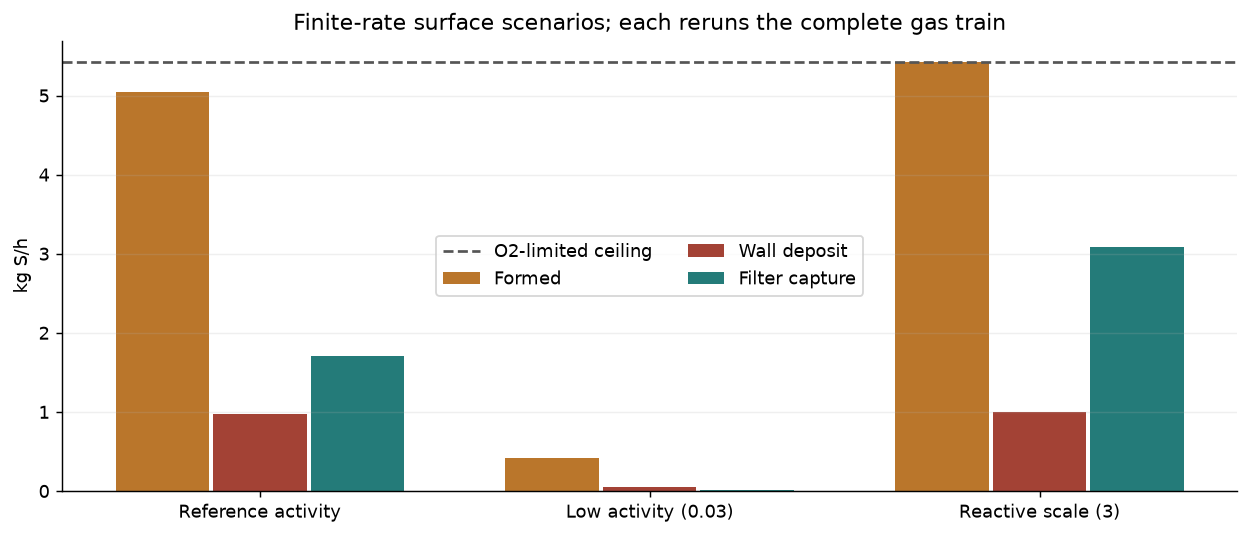

In [15]:
scenario_cases = {"Reference activity": case}
for label, material_factor in [("Low activity (0.03)", 0.03), ("Reactive scale (3)", 3.0)]:
    scenario_cases[label] = run_recompression(base, surface_factor=material_factor)
scenario_rows = []
for label, result in scenario_cases.items():
    checked = case_balance(base, result)
    assert checked["relative_mass_error"] < 1e-6, (label, checked)
    assert checked["relative_S_error"] < 1e-5, (label, checked)
    assert checked["O2_mol_s_error"] < 1e-7, (label, checked)
    assert checked["S_formed_kg_h"] <= oxygen_sulfur_ceiling * (1 + 1e-6)
    scenario_rows.append({
        "Surface scenario": label, "Formed (kg/h)": checked["S_formed_kg_h"],
        "Wall (kg/h)": checked["S_wall_kg_h"], "Filters (kg/h)": checked["S_filters_kg_h"],
        "Export particles (kg/h)": checked["S_mobile_export_kg_h"],
        "O2 in export (mol/s)": molrate(result["gas"], "oxygen"),
    })
sensitivity = pd.DataFrame(scenario_rows)
display(sensitivity.round(5))
fig, ax = plt.subplots(figsize=(9.5, 4))
indices = np.arange(len(sensitivity))
for offset, column, label, color in [(-0.25, "Formed (kg/h)", "Formed", "#ba762b"),
                                    (0.0, "Wall (kg/h)", "Wall deposit", "#a34235"),
                                    (0.25, "Filters (kg/h)", "Filter capture", "#247b79")]:
    ax.bar(indices + offset, sensitivity[column], width=0.24, label=label, color=color)
ax.axhline(oxygen_sulfur_ceiling, color="#555555", ls="--", label="O2-limited ceiling")
ax.set(xticks=indices, xticklabels=sensitivity["Surface scenario"], ylabel="kg S/h",
       title="Finite-rate surface scenarios; each reruns the complete gas train")
ax.legend(ncol=2)
ax.grid(axis="y", alpha=0.2)
plt.show()

In [16]:
purge_rates = np.array([50.0, 200.0, 500.0])
purge_oxygen_percent = np.array([0.0, 0.1, 1.0, 2.0])
bound = np.outer(purge_rates * 101325 / (R_GAS * 288.15), purge_oxygen_percent / 100)
bound *= 2.0 * M_S
display(Markdown(
    "**Oxygen-limited sulfur ceiling (kg/h), assuming excess H2S and full S0 selectivity.**"
))
display(pd.DataFrame(bound, index=[f"{q:g} Sm3/h purge" for q in purge_rates],
                     columns=[f"{p:g}% O2" for p in purge_oxygen_percent]).round(4))
assert np.all(bound[:, 0] == 0.0)
filter_rows = []
for index, tag in [(3, "F-101"), (4, "F-102")]:
    capture = float(rows.iloc[index]["filter_capture_kg_h"])
    capacity_kg = 25.0
    filter_rows.append({"Filter": tag, "Capture (kg S/h)": capture,
                        "Assumed remaining S capacity (kg)": capacity_kg,
                        "Capacity / capture (h)": capacity_kg / capture if capture else np.inf})
display(pd.DataFrame(filter_rows).round(3))

**Oxygen-limited sulfur ceiling (kg/h), assuming excess H2S and full S0 selectivity.**

,0% O2,0.1% O2,1% O2,2% O2
50 Sm3/h purge,0.0,0.1356,1.3561,2.7122
200 Sm3/h purge,0.0,0.5424,5.4244,10.8489
500 Sm3/h purge,0.0,1.3561,13.5611,27.1222


,Filter,Capture (kg S/h),Assumed remaining S capacity (kg),Capacity / capture (h)
0,F-101,1.571,25.0,15.916
1,F-102,0.141,25.0,176.772


The capacity calculation is only $t=M_{capacity}/\dot m_{capture}$ for a constant rate.
It is **not a predicted change-out interval**: the selected 25 kg excludes FeS, rust,
hydrocarbon liquid and other solids, and no cake permeability, bypass, differential
pressure limit or particle-size efficiency curve has been supplied. A filter captures
existing particles; it does not remove the oxygen driving later formation. Increasing
capture can move the inventory into a cake that itself becomes chemically active.

## 8. Corroded feed pipes and reactive deposits: a finite wall inventory

Rust is both a surface and a **finite chemical reagent**. The following balanced screening
reactions explain why an oxygen-free feed pipe can still generate elemental sulfur:

$$\mathrm{Fe_2O_3+3H_2S\rightarrow2FeS+S+3H_2O}$$

$$\mathrm{4FeS+3O_2\rightarrow2Fe_2O_3+4S}$$

Bare iron and iron carbonate can form FeS without directly producing S₀ in these idealized
paths: $\mathrm{Fe+H_2S\rightarrow FeS+H_2}$ and
$\mathrm{FeCO_3+H_2S\rightarrow FeS+CO_2+H_2O}$. Oxidation of existing FeS then produces
sulfur and regenerates oxide; continued H₂S/O₂ supply can sustain cycling. The initial FeS
inventory alone is consequently **not** a cap on long-duration release when fresh H₂S
continues to enter. For oxygen-free oxide sulfidation, 2 kg Fe₂O₃ can produce at most about
0.402 kg elemental sulfur through the first reaction.

This behavior is supported qualitatively by the primary ferrihydrite-column work of
[Cantrell et al. (2003)](https://www.pnnl.gov/publications/oxidation-h2s-iron-oxides-unsaturated-conditions):
H₂S exposure in nitrogen produced FeS and S₀; oxygen changed the product distribution.
Those experiments do not supply transferable rates for this high-pressure process.

We now use native `IronSulfideWallInventory` and `IronSulfideOxidationSource` in a separate
24-hour gas/wet-wall exposure example at 35 °C and 9 bara. Initial inventories are 5 kg
FeS and 2 kg oxide equivalent, with 100 m² geometric area and 50% wetted area. The selected
fractional rates are 0.10 h⁻¹ for oxide sulfidation and 0.05 h⁻¹ for FeS oxidation; oxygen
contact is capped at 20% of the gas O₂ supply. Mackinawite is selected, the elemental
sulfur yield is set to 100% for a closed stoichiometric example, and the native
`kineticsCalibrated` flag remains false. Mineral factors and uncertainty bands are
screening choices, not measured probabilities.

The two cases differ only in oxygen: zero versus 0.1 mol% in the exposure gas. This is a
diluted gas composition, not the 1% O₂ specification of the membrane purge. This side
calculation is **not added to the steady process source**, because that would double-count
surface chemistry already represented by its effective kinetic factor.

In [17]:
def wall_inventory_example(with_oxygen, hours=24.0, time_step_h=0.25):
    """Finite wall exposure, separate from the steady process material balance."""
    wall = neq.process.equipment.reactor.IronSulfideWallInventory(5.0, 0.0, 2.0)
    wall.setPipeSurfaceAreaM2(100.0)
    wall.setWettedFraction(0.5)
    wall.setSurfaceAreaMultiplier(1.0)
    wall.setFeSPhase(neq.process.equipment.reactor.IronSulfideWallInventory.FeSPhase.MACKINAWITE)
    inlet = make_source("Wall exposure gas", {
        "methane": 0.979, "H2S": 0.02,
        "oxygen": 0.001 if with_oxygen else 0.0, "water": 0.001,
    }, 1000.0, 35.0, 9.0)
    source = neq.process.equipment.reactor.IronSulfideOxidationSource(
        "Rust and FeS exposure", inlet, wall
    )
    source.setIronOxideSulfidationFractionPerHour(0.10)
    source.setFeSOxidationFractionPerHour(0.05)
    source.setH2SWallContactFraction(1.0)
    source.setOxygenTransferFraction(0.2)
    source.setElementalSulfurYieldFraction(1.0)
    source.setElementalSulfurYieldBounds(1.0, 1.0)
    source.setKineticUncertaintyFactor(3.0)
    source.setKineticsCalibrated(False)
    source.setSolidFlashEnabled(False)
    records = []
    sulfur_released = 0.0
    h2s_sulfur_to_wall = 0.0
    uuid = jpype.JClass("java.util.UUID")
    for index in range(round(hours / time_step_h)):
        source.runTransient(time_step_h * 3600.0, uuid.randomUUID())
        release = float(source.getElementalSulfurRateKgPerHour())
        sulfur_released += release * time_step_h
        h2s_sulfur_to_wall += (
            float(source.getH2SConsumedKgPerHour()) * M_S / 0.034081
            * time_step_h
        )
        records.append({
            "hour": (index + 1) * time_step_h,
            "S_release_kg_h": release,
            "cumulative_S_kg": sulfur_released,
            "FeS_kg": float(wall.getFeSMassKg()),
            "Fe2O3_equivalent_kg": float(wall.getIronOxideEquivalentMassKg()),
            "O2_consumed_kg_h": float(source.getOxygenConsumedKgPerHour()),
        })
    wall_sulfur_initial = 5.0 / 0.08791 * M_S
    wall_sulfur_final = float(wall.getFeSMassKg()) / 0.08791 * M_S
    sulfur_error = wall_sulfur_initial + h2s_sulfur_to_wall - wall_sulfur_final - sulfur_released
    assert abs(sulfur_error) < 1e-5, sulfur_error
    return pd.DataFrame(records), source, sulfur_error

2 kg Fe2O3 oxygen-free S0 bound: 0.401598 kg
Wall + flowing H2S sulfur inventory errors: 7.22e-16, 0.00e+00 kg
Native kineticsCalibrated: False


,Exposure,hour,S_release_kg_h,cumulative_S_kg,FeS_kg,Fe2O3_equivalent_kg,O2_consumed_kg_h
0,No oxygen,24.0,0.00362,0.36626,7.00829,0.17598,0.00000
1,Oxygen present,24.0,0.13245,3.17816,4.78695,2.19350,0.06617


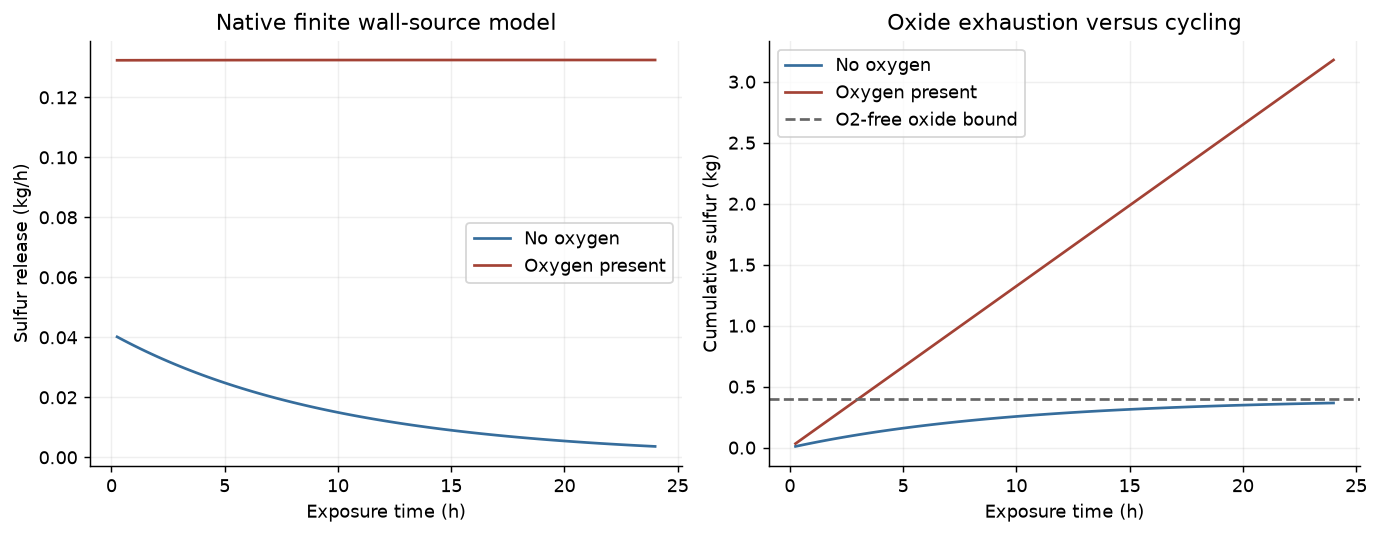

In [18]:
wall_without_o2, native_wall_without, error_without = wall_inventory_example(False)
wall_with_o2, native_wall_with, error_with = wall_inventory_example(True)
oxide_only_bound = 2.0 / 0.159687 * M_S
assert wall_without_o2.iloc[-1]["cumulative_S_kg"] < oxide_only_bound
wall_summary = pd.DataFrame([
    {"Exposure": "No oxygen", **wall_without_o2.iloc[-1].to_dict()},
    {"Exposure": "Oxygen present", **wall_with_o2.iloc[-1].to_dict()},
])
display(wall_summary.round(5))
print(f"2 kg Fe2O3 oxygen-free S0 bound: {oxide_only_bound:.6f} kg")
print(f"Wall + flowing H2S sulfur inventory errors: {error_without:.2e}, {error_with:.2e} kg")
print("Native kineticsCalibrated:", native_wall_with.getResults().get("kineticsCalibrated"))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for frame, label, color in [(wall_without_o2, "No oxygen", "#366d9c"),
                            (wall_with_o2, "Oxygen present", "#a34235")]:
    axes[0].plot(frame["hour"], frame["S_release_kg_h"], label=label, color=color)
    axes[1].plot(frame["hour"], frame["cumulative_S_kg"], label=label, color=color)
axes[0].set(xlabel="Exposure time (h)", ylabel="Sulfur release (kg/h)",
    title="Native finite wall-source model")
axes[1].set(xlabel="Exposure time (h)", ylabel="Cumulative sulfur (kg)",
    title="Oxide exhaustion versus cycling")
axes[1].axhline(oxide_only_bound, ls="--", color="#666666", label="O2-free oxide bound")
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.show()

## 9. Material and location interpretation

| Location/material | Mechanism to evaluate | How to use the model |
|---|---|---|
| Corroded upstream feed pipe | Wet rust sulfidation can form S₀ with no O₂; FeS stores sulfur for later oxidation | Add measured oxide/FeS inventory and residence/contact information; do not infer it from roughness alone |
| Clean/passivated metal | Different available reactive surface; oxygen may survive farther downstream | Low-activity sensitivity demonstrates relocation of formation, not an alloy guarantee |
| Carbon steel with reactive scale | Larger effective area, oxide reduction, FeS oxidation and nucleation | Separate catalytic surface rate from finite consumable scale inventory; use mineral analysis |
| FGR tie-in and LP scrubber | First H₂S/O₂ contact; stagnant wet pockets can have longer exposure than bulk gas | Compare local O₂, water, hold-up and contact area with the first-zone assumptions |
| Compressors and hot metal | Short bulk residence; wall temperature and surface chemistry differ from gas temperature | Use the homogeneous transit screen only as a limited comparison; assess hot surfaces separately |
| Interstage coolers and knockout drums | Cooling changes sulfur solubility; condensate can carry dissolved S₈ away | Read formed, precipitated and liquid-drain quantities separately |
| Clean particulate filter | Captures solids according to size and efficiency; passes dissolved sulfur and O₂ | Use measured capture curves and pressure drop; the constant-efficiency ledger is a screening model |
| FeS/rust-loaded filter or coalescer | High area and long retention can make the cake an additional reaction site | Apply a finite-inventory exposure model to measured cake composition; include liquid films |
| Sulfur dissolved in stabilized oil/condensate | Can remain mobile at current conditions and precipitate after later cooling or flashing | Extend the phase study along the actual liquid export or recycle route |
| Cold downstream/export pipe | Remaining O₂ can make fresh sulfur after the last filter; deposition depends on transport | Compare export formation and particle payload; add wall temperature, diameter, velocity and retention data |

The native wall example releases S₀ into the stream; it does not calculate how much stays
attached to the original rust or FeS layer. Neither a positive equilibrium saturation
index nor a positive source rate proves a deposit. A deposition assessment also needs
nucleation/supersaturation behavior, aerosol size, residence time, transport to the wall,
sticking, re-entrainment, wet-film effects and local wall temperature. FeS oxidation can
also release heat in retained deposits; the isothermal models here cannot resolve it.

## 10. Separator carryover: native functionality and a clear mass basis

NeqSim's `ThreePhaseSeparator.setEntrainment()` transfers a specified amount of one
phase into another outlet. Here **0.1% carryover means 0.1% of the separator-feed oil
phase**, not 0.1% liquid in the gas. The example reruns the 33 bara production separator
and checks all three outlet masses. With this oil-rich feed, a small loss of oil recovery
can create a substantial compressor liquid load.

For equipment rating, NeqSim also has `setEnhancedEntrainmentCalculation(True)`,
`SeparatorPerformanceCalculator`, droplet-size distributions and mist-eliminator grade
efficiency curves. These require vessel geometry, internals, operating levels and inlet
conditions; the specified fractions below are sensitivity inputs, not predicted separator
performance. See the [native entrainment documentation](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/docs/process/equipment/separator-entrainment-modeling.md).

In [19]:
ThreePhaseSeparator = neq.process.equipment.separator.ThreePhaseSeparator
Compressor = neq.process.equipment.compressor.Compressor
CompressorDeposit = neq.process.equipment.compressor.CompressorDeposit
DepositMechanism = neq.process.equipment.compressor.DepositMechanism
CompressorDepositWash = neq.process.equipment.compressor.CompressorDepositWash
WashFluid = neq.process.equipment.compressor.WashFluid

carryover_rows = []
reference_gas_mass = mass_rate(base["gas"][0])
reference_oil_mass = mass_rate(base["separators"][0].getOilOutStream())
reference_gas_sm3_h = float(base["gas"][0].getFlowRate("mol/sec"))
reference_gas_sm3_h *= R_GAS * 288.15 / 101325.0 * 3600.0
for fraction in [0.0, 0.0001, 0.001, 0.01]:
    separator = ThreePhaseSeparator("HP carryover sensitivity", base["feed"].clone())
    separator.setEntrainment(fraction, "mass", "feed", "oil", "gas")
    separator.run()
    outlets = [separator.getGasOutStream(), separator.getOilOutStream(),
               separator.getWaterOutStream()]
    transferred = mass_rate(outlets[0]) - reference_gas_mass
    closure = sum(mass_rate(stream) for stream in outlets) - mass_rate(base["feed"])
    assert abs(closure) < 0.01
    assert abs(transferred - fraction * reference_oil_mass) < 0.01
    carryover_rows.append({
        "Feed-oil carryover (%)": 100.0 * fraction,
        "Transferred oil (kg/h)": transferred,
        "Transferred oil (mg/Sm3 gas)": transferred * 1e6 / reference_gas_sm3_h,
        "Gas-outlet total (kg/h)": mass_rate(outlets[0]),
        "Outlet mass error (kg/h)": closure,
    })
carryover_table = pd.DataFrame(carryover_rows)
display(carryover_table.round(4))

,Feed-oil carryover (%),Transferred oil (kg/h),Transferred oil (mg/Sm3 gas),Gas-outlet total (kg/h),Outlet mass error (kg/h)
0,0.00,0.0000,0.0000,14340.9699,-0.0
1,0.01,8.4753,511.0513,14349.4452,-0.0
2,0.10,84.7532,5110.5128,14425.7230,-0.0
3,1.00,847.5316,51105.1281,15188.5015,-0.0


## 11. Oil versus condensate entering compressor 3

This controlled side study uses the actual **33 bara, 32°C suction gas and 90 bara
discharge pressure** of compressor 3. The liquid compositions come from the HP production
separator oil and the HP interstage knockout condensate. Add 0, 50 or 200 kg/h of either
source while retaining the same starting gas flow. The amounts are hypothetical upset
loads, not allowable compressor limits; the 200 kg/h condensate case is an extrapolation
beyond that drum's baseline condensate flow. Heavy oil can also arrive through upstream
separator carryover, while condensate can form between a separator and the compressor.

The mixture is flashed at suction conditions before compression. Thus **added liquid
mass and equilibrium liquid mass at suction can differ**: the added oil changes the
solvent inventory and can condense additional material from the gas. Both are reported.
Sm³ refers to an ideal-gas molar volume at 15°C and 1.01325 bara throughout this study.

The native `Compressor` uses ten pressure steps and a specified **0.75 polytropic
efficiency**. This differs from the main train's 0.75 isentropic assumption. Reaction and
solid capture are frozen in this thermal calculation; the existing mobile-solid payload
is assessed separately in section 12. Vapor/liquid redistribution is at equilibrium.
Droplet slip, finite evaporation time, impact, blade erosion, vibration and seals are not
solved by this calculation. A lower discharge temperature or calculated duty therefore
does not demonstrate that liquid ingestion is acceptable. Wet-compression experiments
also require separate thermal-equilibrium and aerodynamic assessment [5, 6].

In [20]:
def phase_mass_kg_h(stream, phase_name):
    fluid = stream.getFluid()
    if not fluid.hasPhaseType(phase_name):
        return 0.0
    phase = fluid.getPhase(phase_name)
    return float(phase.getNumberOfMolesInPhase() * phase.getMolarMass()) * 3600.0


def compression_side_case(feed, deposit=None):
    machine = Compressor("C3 controlled comparison", feed.clone())
    machine.setOutletPressure(90.0)
    machine.setUsePolytropicCalc(True)
    machine.setPolytropicEfficiency(0.75)
    machine.setPolytropicMethod("detailed")
    machine.setNumberOfCompressorCalcSteps(10)
    if deposit is not None:
        machine.setDepositModel(deposit)
    machine.run()
    outlet = machine.getOutletStream()
    assert abs(mass_rate(feed) - mass_rate(outlet)) < 0.01
    incoming = inventory_rates(feed.getFluid())
    outgoing = component_rates(outlet.getFluid())
    for name, value in incoming.items():
        assert abs(value - outgoing.get(name, 0.0)) < 1e-6 * max(1.0, value)
    feed.getFluid().init(3)
    outlet.getFluid().init(3)
    enthalpy_change = float(outlet.getFluid().getEnthalpy() - feed.getFluid().getEnthalpy())
    power_w = float(machine.getPower())
    assert abs(enthalpy_change - power_w) < max(1.0, 1e-5 * power_w)
    assert np.isfinite(power_w) and power_w > 0.0
    return machine


carrier = case["compressors"][2].getInletStream().clone()
cold_header = case["named"]["MP discharge cooler / HP scrubber before reaction"]
liquid_templates = {
    "Oil": base["separators"][0].getOilOutStream().getFluid(),
    "Condensate": cold_header.getFluid().phaseToSystem("oil"),
}


def add_liquid_source(label, added_kg_h):
    template = liquid_templates[label]
    rates = inventory_rates(carrier.getFluid())
    source_mass = float(template.getFlowRate("kg/hr"))
    for name, value in inventory_rates(template).items():
        rates[name] = rates.get(name, 0.0) + value * added_kg_h / source_mass
    fluid = fluid_with_rates(carrier.getFluid(), rates)
    feed = run_stream(f"C3 with {label.lower()} carryover", fluid)
    assert abs(mass_rate(feed) - mass_rate(carrier) - added_kg_h) < 0.01
    return feed


wet_cases = {}
wet_rows = []
for label in liquid_templates:
    for added_kg_h in [0.0, 50.0, 200.0]:
        feed = add_liquid_source(label, added_kg_h)
        machine = compression_side_case(feed)
        outlet = machine.getOutletStream()
        oil_in = phase_mass_kg_h(feed, "oil")
        water_in = phase_mass_kg_h(feed, "aqueous")
        oil_out = phase_mass_kg_h(outlet, "oil")
        wet_cases[(label, added_kg_h)] = (feed, machine)
        wet_rows.append({
            "Liquid source": label,
            "Added (kg/h)": added_kg_h,
            "Suction HC liquid (kg/h)": oil_in,
            "Suction water (kg/h)": water_in,
            "Suction liquid (wt%)": 100.0 * (oil_in + water_in) / mass_rate(feed),
            "Discharge HC liquid (kg/h)": oil_out,
            "Power (kW)": float(machine.getPower("kW")),
            "Discharge T (C)": float(outlet.getTemperature("C")),
        })
wet_table = pd.DataFrame(wet_rows)
display(wet_table.round(4))
print("Local mixture, per-component and compressor enthalpy balances passed.")

Local mixture, per-component and compressor enthalpy balances passed.


,Liquid source,Added (kg/h),Suction HC liquid (kg/h),Suction water (kg/h),Suction liquid (wt%),Discharge HC liquid (kg/h),Power (kW),Discharge T (C)
0,Oil,0.0,0.0000,0.0000,0.0000,0.0000,809.9152,120.8749
1,Oil,50.0,113.0962,0.0311,0.6363,18.9215,807.9529,119.9877
2,Oil,200.0,354.2493,0.1013,1.9763,115.3002,804.9425,118.3413
3,Condensate,0.0,0.0000,0.0000,0.0000,0.0000,809.9152,120.8749
4,Condensate,50.0,49.7673,0.0000,0.2799,0.0000,808.8491,120.3504
5,Condensate,200.0,199.6772,0.0000,1.1136,0.0000,806.0500,118.8230


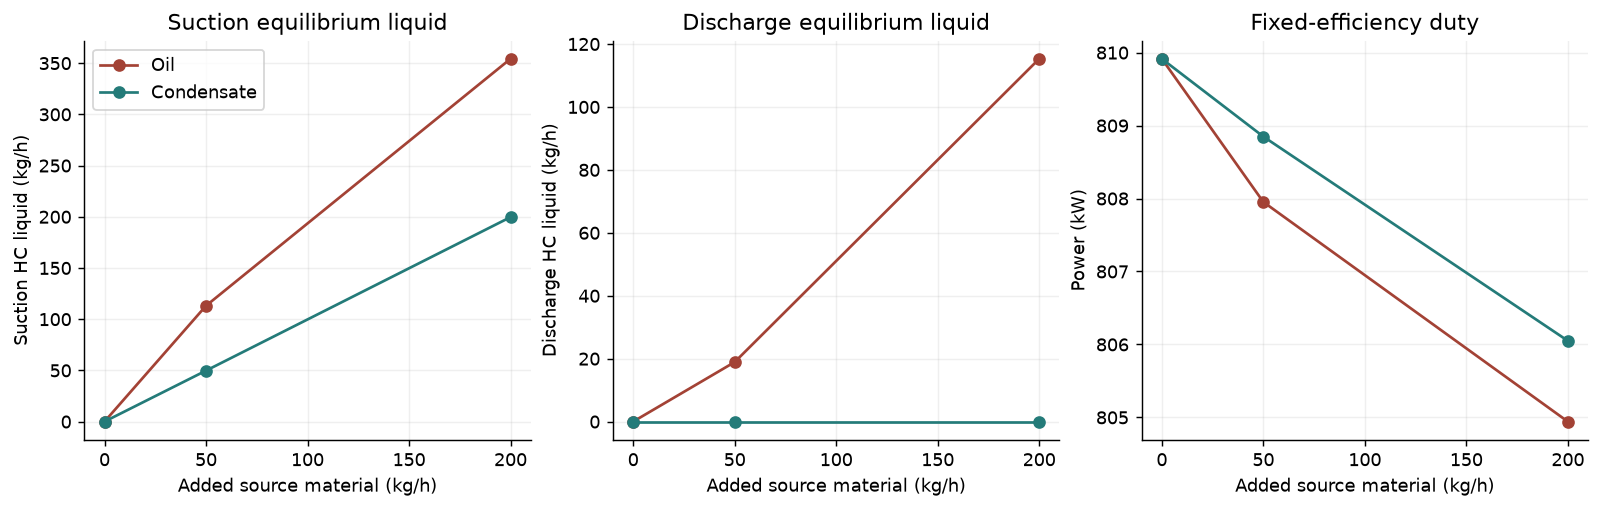

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8), layout="constrained")
for label, color in [("Oil", "#a34235"), ("Condensate", "#247b79")]:
    subset = wet_table[wet_table["Liquid source"] == label]
    for ax, column, title in zip(
        axes,
        ["Suction HC liquid (kg/h)", "Discharge HC liquid (kg/h)", "Power (kW)"],
        ["Suction equilibrium liquid", "Discharge equilibrium liquid", "Fixed-efficiency duty"],
    ):
        ax.plot(subset["Added (kg/h)"], subset[column], "o-", label=label, color=color)
        ax.set(xlabel="Added source material (kg/h)", ylabel=column, title=title)
        ax.grid(alpha=0.2)
axes[0].legend()
plt.show()

## 12. Deposit buildup and compressor degradation

Oil can wet surfaces and retain sulfur or corrosion particles; condensate may dissolve
some deposits, evaporate, or leave a residue. Which effect dominates depends on liquid
composition, temperature, particle size, wettability and residence time. **Neither every
entrained kilogram nor every precipitated kilogram becomes compressor deposit.**

Use NeqSim's native `CompressorDeposit` to accumulate hydrocarbon residue and the **mobile
S₈ particles leaving the HP scrubber** from the sulfur calculation. Dissolved S₈, FeS,
salt, scale and additional hot-surface reaction are excluded from this deposit inventory.
No phase profile from `SolidFlashDepositSource` is used because it calls the solid-flash
route discussed in issue #3622. This side study does not subtract deposits from the
main-train sulfur ledger or alter its previously reported export results.

The explicitly assumed residue yield is 0.01% of HC liquid exposed to the compressor
for oil and 0.001% for condensate; these combine residue formation and retention. They
are **sensitivity coefficients, not kinetic measurements or an EOS wax prediction**.
`HYDROCARBON_WAX` is used only as the native inventory category for hydrocarbon residue
with its 900 kg/m³ density. The sulfur capture fraction is 0.5%. Each case holds its
loading constant for 720 h. Geometry is an assumed 6 m² foulable area and 10 mm passage
half-height. Change these values or fit them to measured clean/degraded performance.

The S₈ inventory represents assumed net retention near the cold suction and early stages. Hotter sections can exceed sulfur's melting range; melting, dissolution and re-entrainment may then change retention. This is not a prediction of a solid sulfur coating throughout the compressor.

The native relations are:

$$V_d=\sum_i m_i/\rho_i,\qquad b=V_d/(A_w h),\qquad \eta_p=\eta_{p,0}(1-1.6b),\qquad H/H_0=(1-b)^2.$$

The implementation has lower/upper clamps; the examples below assert they remain well
away from them. We rerun the same gas and pressure duty with the degraded polytropic
efficiency to isolate fouling from immediate liquid effects. The head multiplier describes
the model's available-head loss at a comparable map point. **Fixed outlet pressure does
not prove the real compressor can attain it**: speed, driver limit, surge and choke need
an OEM map. The model does not predict erosion rate, imbalance, remaining life or a
maintenance interval. Fouling may be recoverable by cleaning; erosion and corrosion loss
generally require inspection and repair. Native API details are in [7].

In [22]:
DEPOSIT_AREA_M2 = 6.0
PASSAGE_HALF_HEIGHT_M = 0.010
SULFUR_STICKING = 0.005
RESIDUE_YIELD = {"Oil": 1e-4, "Condensate": 1e-5}


def deposit_inventory(hours, hydrocarbon_rate, sulfur_particle_rate,
                      residue_yield=RESIDUE_YIELD["Oil"], rate_factor=1.0):
    deposit = CompressorDeposit(DEPOSIT_AREA_M2, PASSAGE_HALF_HEIGHT_M)
    deposit.accumulate(
        DepositMechanism.HYDROCARBON_WAX,
        hydrocarbon_rate * residue_yield * rate_factor,
        float(hours),
    )
    deposit.accumulate(
        DepositMechanism.SULFUR_S8,
        sulfur_particle_rate * SULFUR_STICKING * rate_factor,
        float(hours),
    )
    expected = hours * rate_factor * (
        hydrocarbon_rate * residue_yield + sulfur_particle_rate * SULFUR_STICKING
    )
    assert abs(float(deposit.getTotalDepositMass()) - expected) < 1e-9
    return deposit


particle_rate_c3 = float(rows.iloc[2]["mobile_S_kg_h"])
oil_wet_feed = wet_cases[("Oil", 50.0)][0]
condensate_wet_feed = wet_cases[("Condensate", 50.0)][0]
oil_exposure = phase_mass_kg_h(oil_wet_feed, "oil")
condensate_exposure = phase_mass_kg_h(condensate_wet_feed, "oil")
print(f"Baseline mobile sulfur supplied to C3: {particle_rate_c3:.6f} kg S/h")
print(f"Oil-case HC liquid exposure at suction: {oil_exposure:.4f} kg/h")
print(f"Condensate-case HC liquid exposure at suction: {condensate_exposure:.4f} kg/h")

degradation_rows = []
clean_machine = wet_cases[("Oil", 0.0)][1]
clean_power = float(clean_machine.getPower("kW"))
for label, exposure in [("Oil", oil_exposure), ("Condensate", condensate_exposure)]:
    for hours in [0.0, 168.0, 336.0, 720.0]:
        deposit = deposit_inventory(
            hours, exposure, particle_rate_c3, residue_yield=RESIDUE_YIELD[label]
        )
        assert float(deposit.getAreaBlockageFraction()) < 0.30
        machine = compression_side_case(carrier, deposit)
        degradation_rows.append({
            "Liquid source": label,
            "Hours": hours,
            "HC residue (kg)": float(deposit.getDepositMass(DepositMechanism.HYDROCARBON_WAX)),
            "S deposit (kg)": float(deposit.getDepositMass(DepositMechanism.SULFUR_S8)),
            "Efficiency (%)": 100.0 * float(machine.getPolytropicEfficiency()),
            "Head multiplier": float(deposit.getHeadMultiplier()),
            "Power (kW)": float(machine.getPower("kW")),
            "Discharge T (C)": float(machine.getOutletStream().getTemperature("C")),
        })
degradation_table = pd.DataFrame(degradation_rows)
display(degradation_table.round(4))

Baseline mobile sulfur supplied to C3: 1.444901 kg S/h
Oil-case HC liquid exposure at suction: 113.0962 kg/h
Condensate-case HC liquid exposure at suction: 49.7673 kg/h


,Liquid source,Hours,HC residue (kg),S deposit (kg),Efficiency (%),Head multiplier,Power (kW),Discharge T (C)
0,Oil,0.0,0.0000,0.0000,75.0000,1.0000,809.9152,120.8749
1,Oil,168.0,1.9000,1.2137,69.6051,0.9121,881.0999,126.3660
2,Oil,336.0,3.8000,2.4274,64.2101,0.8283,965.8146,132.8905
3,Oil,720.0,8.1429,5.2016,51.8789,0.6518,1236.2139,153.5992
4,Condensate,0.0,0.0000,0.0000,75.0000,1.0000,809.9152,120.8749
5,Condensate,168.0,0.0836,1.2137,73.6415,0.9775,826.7453,122.1737
6,Condensate,336.0,0.1672,2.4274,72.2831,0.9552,844.2820,123.5267
7,Condensate,720.0,0.3583,5.2016,69.1780,0.9053,887.2671,126.8414


The rate-factor range is a sensitivity range, not a statistical confidence interval.


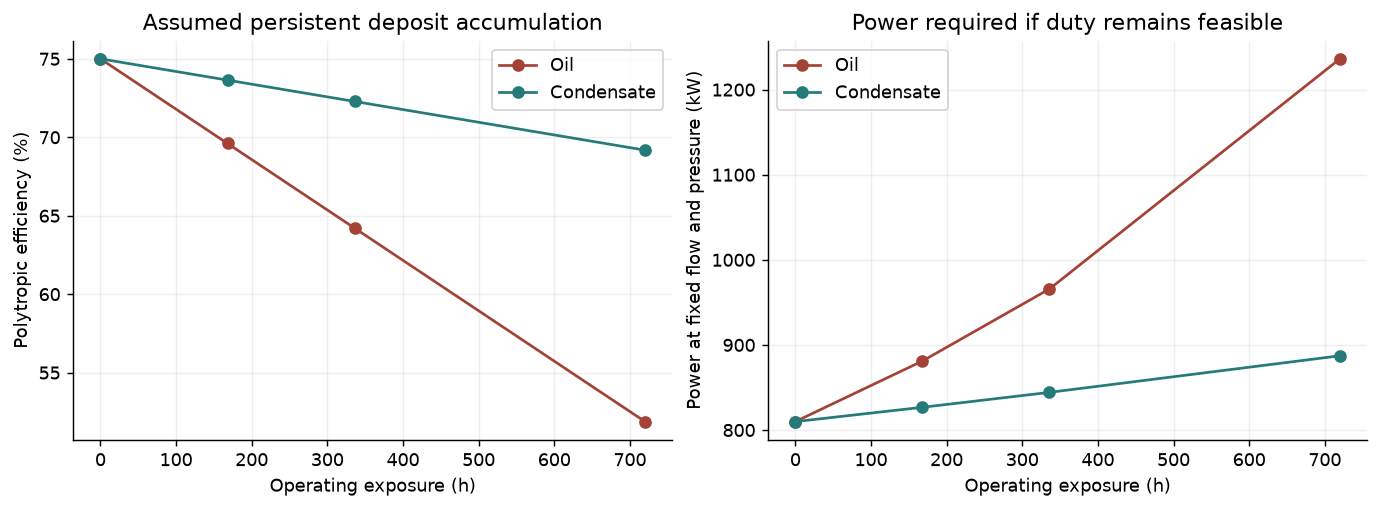

,Assumed deposition-rate factor,Deposit after 720 h (kg),Efficiency multiplier,Head multiplier
0,0.1,1.33446,0.96917,0.96184
1,1.0,13.34457,0.69172,0.65177
2,1.5,20.01685,0.53758,0.50550


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), layout="constrained")
for label, color in [("Oil", "#a34235"), ("Condensate", "#247b79")]:
    subset = degradation_table[degradation_table["Liquid source"] == label]
    axes[0].plot(subset["Hours"], subset["Efficiency (%)"], "o-", label=label, color=color)
    axes[1].plot(subset["Hours"], subset["Power (kW)"], "o-", label=label, color=color)
axes[0].set(ylabel="Polytropic efficiency (%)", title="Assumed persistent deposit accumulation")
axes[1].set(ylabel="Power at fixed flow and pressure (kW)",
    title="Power required if duty remains feasible")
for ax in axes:
    ax.set_xlabel("Operating exposure (h)")
    ax.legend()
    ax.grid(alpha=0.2)
plt.show()

uncertainty_rows = []
for factor in [0.1, 1.0, 1.5]:
    deposit = deposit_inventory(720.0, oil_exposure, particle_rate_c3, rate_factor=factor)
    assert float(deposit.getAreaBlockageFraction()) < 0.30
    uncertainty_rows.append({
        "Assumed deposition-rate factor": factor,
        "Deposit after 720 h (kg)": float(deposit.getTotalDepositMass()),
        "Efficiency multiplier": float(deposit.getEfficiencyMultiplier()),
        "Head multiplier": float(deposit.getHeadMultiplier()),
    })
display(pd.DataFrame(uncertainty_rows).round(5))
print("The rate-factor range is a sensitivity range, not a statistical confidence interval.")

## 13. Compare potential solutions

The first comparison applies a **native additional suction scrubber** to the 50 kg/h
oil case. It transfers 1% of its equilibrium oil phase and 1% of its aqueous phase to
the gas outlet (99% removal of each liquid phase on a feed basis). This is a specified
scrubber/coalescer performance target, not an achieved grade efficiency. The incremental
particle filter captures an assumed 90% of incoming mobile S₈. These are separate
efficiencies for separate phases; neither removes oxygen or vapor-phase sulfur.

The combined option also lowers O₂ in the 200 Sm³/h membrane purge from **1% to 0.1%**
and reruns the full sulfur process to obtain the new particle supply. This could represent
a qualified higher-purity nitrogen source or revised purge/recovery arrangement. The
notebook does not assume that a membrane setting alone can deliver the target.

The comparison holds suction temperature and pressure fixed and assumes zero additional
pressure drop. Actual coalescer/filter pressure loss, replacement cost, drainage capacity
and any nitrogen-package penalty must be added for an economic decision. Gas duty below
uses the same reference carrier to isolate the **degradation reduction**. The local
scrubber's conserved gas and liquid outputs are shown separately.

A zero local particle load in the lower-O₂ case means no mobile solid survives that
particular scrubber flash in this model. It does not mean zero sulfur formation or zero
downstream risk: dissolved sulfur and residual oxygen can continue through the train.

In [24]:
mitigation_scrubber = ThreePhaseSeparator("Additional C3 suction scrubber", oil_wet_feed.clone())
mitigation_scrubber.setEntrainment(0.01, "mass", "feed", "oil", "gas")
mitigation_scrubber.setEntrainment(0.01, "mass", "feed", "aqueous", "gas")
mitigation_scrubber.run()
scrubber_outlets = [
    mitigation_scrubber.getGasOutStream(),
    mitigation_scrubber.getOilOutStream(),
    mitigation_scrubber.getWaterOutStream(),
]
assert abs(sum(mass_rate(s) for s in scrubber_outlets) - mass_rate(oil_wet_feed)) < 0.01
hc_removed = mass_rate(scrubber_outlets[1])
hc_residual = max(0.0, oil_exposure - hc_removed)
assert abs(hc_residual / oil_exposure - 0.01) < 1e-4
display(pd.DataFrame({
    "Scrubber outlet": ["Gas with residual carryover", "Hydrocarbon drain", "Water drain"],
    "Mass (kg/h)": [mass_rate(s) for s in scrubber_outlets],
}).round(5))

low_oxygen_case = run_recompression(base, oxygen_fraction=0.001)
low_oxygen_balance = case_balance(base, low_oxygen_case)
assert low_oxygen_balance["relative_mass_error"] < 1e-6
assert low_oxygen_balance["relative_S_error"] < 1e-5
assert low_oxygen_balance["O2_mol_s_error"] < 1e-7
low_o2_particles = float(low_oxygen_case["rows"].iloc[2]["mobile_S_kg_h"])

mitigation_inputs = [
    ("Unmitigated", oil_exposure, particle_rate_c3),
    ("Liquid + particle removal", hc_residual, 0.10 * particle_rate_c3),
    ("Removal + lower O2", hc_residual, 0.10 * low_o2_particles),
]
mitigation_rows = []
for label, liquid_rate, solid_rate in mitigation_inputs:
    deposit = deposit_inventory(720.0, liquid_rate, solid_rate)
    machine = compression_side_case(carrier, deposit)
    mitigation_rows.append({
        "Option": label,
        "HC liquid exposed (kg/h)": liquid_rate,
        "S particles exposed (kg/h)": solid_rate,
        "720 h deposit (kg)": float(deposit.getTotalDepositMass()),
        "Efficiency (%)": 100.0 * float(machine.getPolytropicEfficiency()),
        "Head multiplier": float(deposit.getHeadMultiplier()),
        "Added duty from fouling (kW)": float(machine.getPower("kW")) - clean_power,
    })
mitigation_table = pd.DataFrame(mitigation_rows)
display(mitigation_table.round(5))
display(pd.DataFrame([
    {"Purge O2 (%)": 1.0, "Whole-train S formed (kg/h)": balance["S_formed_kg_h"]},
    {"Purge O2 (%)": 0.1, "Whole-train S formed (kg/h)": low_oxygen_balance["S_formed_kg_h"]},
]).round(5))

,Scrubber outlet,Mass (kg/h)
0,Gas with residual carryover,17668.30657
1,Hydrocarbon drain,111.96520
2,Water drain,0.03080


,Option,HC liquid exposed (kg/h),S particles exposed (kg/h),720 h deposit (kg),Efficiency (%),Head multiplier,Added duty from fouling (kW)
0,Unmitigated,113.09616,1.44490,13.34457,51.87887,0.65177,426.29875
1,Liquid + particle removal,1.13096,0.14449,0.60159,74.31647,0.98864,8.38261
2,Removal + lower O2,1.13096,0.00000,0.08143,74.81905,0.99699,2.20258


,Purge O2 (%),Whole-train S formed (kg/h)
0,1.0,5.04611
1,0.1,0.50461


### Cleaning: native inventory removal and its limits

`CompressorDepositWash` can remove the fraction of each deposit that its solvent matrix
allows. The following **normalized 100 kg solvent comparison** is for model inspection,
not an online injection procedure. Contact efficiency is assumed to be 0.7. Native
solubilities are screening constants and have no fitted temperature, pressure or liquid
composition dependence here. Compare water, condensate and xylene to see why a cleaning
fluid must match the deposit; this does not select a field solvent. A real cleaning plan
requires deposit sampling, dissolution testing and OEM review of seals, materials,
droplet loading, injection method, drainage, downstream handling and ignition/toxicity
controls. Do not route uncontrolled liquid into the compressor as a washing strategy.

In [25]:
wash_rows = []
for fluid in [WashFluid.WATER, WashFluid.CONDENSATE, WashFluid.XYLENE]:
    deposit = deposit_inventory(720.0, oil_exposure, particle_rate_c3)
    before = float(deposit.getTotalDepositMass())
    washer = CompressorDepositWash()
    washer.setContactEfficiency(0.7)
    result = washer.wash(deposit, fluid, 100.0, 1.0)
    removed = float(result.getTotalRemovedKg())
    remaining = float(deposit.getTotalDepositMass())
    assert abs(before - removed - remaining) < 1e-9
    wash_rows.append({
        "Native solvent case": str(fluid.getDisplayName()),
        "Contacted solvent (kg)": 100.0,
        "Removed deposit (kg)": removed,
        "Remaining deposit (kg)": remaining,
        "Efficiency multiplier after": float(deposit.getEfficiencyMultiplier()),
    })
wash_table = pd.DataFrame(wash_rows)
display(wash_table.round(5))

,Native solvent case,Contacted solvent (kg),Removed deposit (kg),Remaining deposit (kg),Efficiency multiplier after
0,Water,100.0,0.00000,13.34457,0.69172
1,Condensate,100.0,7.35000,5.99457,0.90363
2,Xylene,100.0,9.54292,3.80164,0.95103


### Measures to evaluate on the actual plant

| Measure | Problem addressed | Required check or trade-off |
|---|---|---|
| Verify membrane-N₂ O₂ content and FGR tie-in | Ongoing H₂S oxidation source | Measure O₂ at the package and mixed header, including upset operation; assess qualified higher-purity supply or recovery routing without compromising flare purge duties |
| Restore separator levels, drains and internals | Bulk oil/water carryover, foaming and slugs | Check level instruments, high-level protection, demister damage/flooding, inlet momentum and turndown; use actual geometry in the native entrainment model |
| Suction KO drum after the last cooling/condensation point | Liquids formed after an upstream separator | Check slug capacity, drain reliability and suction-line low points; a nominally dry separator outlet can cool and condense again |
| Drainable coalescer plus solids protection | Fine oil/condensate aerosols and transported particles | Use measured size-dependent efficiency and loading; monitor differential pressure and drains; rust/S₈ can plug media or create reactive wet cake [8] |
| Control water and corrosive deposits | Aqueous reaction sites, corrosion products and wet sulfur attack | Assess dehydration position, corrosion inhibition, inspection and removal of loose scale; treating water does not remove O₂ or all oil mist |
| Material selection and surface condition | Corrosion, nucleation, adhesion and retained reactive scale | Inspect wet carbon steel and FeS/rust deposits; assess compatible alloys/coatings and filter media with the corrosion/materials team. No universal alloy ranking follows from a single activity factor |
| Deposit-specific cleaning and inspection | Recoverable fouling versus permanent damage | Compare clean/degraded corrected performance, deposit composition and OEM wash limits; inspect erosion/corrosion and balance the rotor if required |
| Operating and condition monitoring | Early identification of liquid or solids ingestion | Trend liquid carryover, O₂, H₂S, filter ΔP, drain flow, corrected head/efficiency, discharge temperature, vibration and power at comparable gas composition/speed |

Oil-rich fouling, sulfur particles and FeS can act together. A corroded feed pipe can add
both a finite chemical sulfur source and particles that seed deposits; a coated or clean
pipe has different surface activity but does not prevent oxidation elsewhere. A filter
cake may become an H₂S/O₂ reaction site, so its captured solids require chemical analysis
as well as a pressure-drop history. A wet oil film can capture particles or dissolve
sulfur, then release it after cooling or evaporation. Those competing transport effects
must be calibrated; they are not implied by the chosen residue yield.

For machinery, fine aerosol fouling, repeated droplet impact/erosion and an occasional
liquid slug are different failure modes. Equilibrium flashes and a deposit-to-efficiency
correlation address only part of the assessment. Check the compressor's permitted liquid
envelope, droplet distribution, tip speed, material/coating, exposure history and actual
surge/control map. A machine designed and qualified for wet gas is a separate equipment
choice from operating a conventional gas compressor with accidental carryover.

The most direct combined strategy in this example is to **reduce the oxygen source,
remove liquids and particles before compression, and manage existing reactive deposits**.
Cleaning recovers the assumed removable inventory; it does not eliminate the source of
new fouling or repair erosion. Temperature changes can relocate both sulfur and
hydrocarbon condensation and therefore need a full process check.

## 14. Results, validation level, and development follow-up

The following summary is generated from the executed case, so it stays consistent when
inputs change. The evidence achieved is independent thermochemical/stoichiometric bounds,
conservation, and scenario trends. There is no plant benchmark or fitted rate/deposition
dataset. The sulfur EOS/solid parameters and heavy-fluid interaction parameters also need
validation against a suitable solubility dataset before use for a specific asset.

In [26]:
display(Markdown(
    f"**For this synthetic case:** the O2 budget permits **{oxygen_sulfur_ceiling:.3f} kg S/h**. "
    f"Finite-rate formation is **{balance['S_formed_kg_h']:.3f} kg/h**. "
    f"Terminal sinks are **{balance['S_wall_kg_h']:.3f} kg/h on walls**, "
    f"**{balance['S_filters_kg_h']:.3f} kg/h in filters**, and "
    f"**{rows['liquid_S_kg_h'].sum():.3f} kg/h in liquid drains**. "
    f"Export carries **{balance['S_mobile_export_kg_h']:.3f} kg/h of mobile solid** plus "
    f"**{rows.iloc[-1]['gas_S_kg_h']:.3f} kg/h dissolved in the gas**.\n\n"
    f"The final export-line zone alone forms **{rows.iloc[-1]['formed_S_kg_h']:.3f} kg/h** "
    "after the filters. Thus removing particles at a filter does not eliminate the "
    "remaining chemical source. Relative total-mass and sulfur-balance errors are "
    f"**{balance['relative_mass_error']:.2e}** and **{balance['relative_S_error']:.2e}**. "
    "These small numerical residuals support the bookkeeping; they do not validate "
    "the assumed kinetic or retention coefficients."
))

oil_end = degradation_table.query("`Liquid source` == 'Oil' and Hours == 720").iloc[0]
best_option = mitigation_table.iloc[-1]
display(Markdown(
    f"**Carryover extension:** native 0.1% carryover of feed oil transfers "
    f"**{carryover_table.iloc[2]['Transferred oil (kg/h)']:.2f} kg/h** into the HP gas outlet. "
    f"In the separate 50 kg/h oil-addition case, suction equilibrium contains "
    f"**{oil_exposure:.2f} kg/h HC liquid**, including material condensed from the gas. "
    f"With the chosen residue and sulfur capture rates, the 720 h oil case gives "
    f"**{oil_end['Efficiency (%)']:.2f}% polytropic efficiency**. "
    f"The combined removal/lower-O2 case gives "
    f"**{best_option['Efficiency (%)']:.2f}%** on the same carrier duty. "
    "These are assumed fouling scenarios, not measured degradation or allowable carryover."
))

**For this synthetic case:** the O2 budget permits **5.424 kg S/h**. Finite-rate formation is **5.046 kg/h**. Terminal sinks are **0.973 kg/h on walls**, **1.712 kg/h in filters**, and **0.775 kg/h in liquid drains**. Export carries **1.465 kg/h of mobile solid** plus **0.121 kg/h dissolved in the gas**.

The final export-line zone alone forms **1.899 kg/h** after the filters. Thus removing particles at a filter does not eliminate the remaining chemical source. Relative total-mass and sulfur-balance errors are **5.13e-09** and **1.56e-07**. These small numerical residuals support the bookkeeping; they do not validate the assumed kinetic or retention coefficients.

**Carryover extension:** native 0.1% carryover of feed oil transfers **84.75 kg/h** into the HP gas outlet. In the separate 50 kg/h oil-addition case, suction equilibrium contains **113.10 kg/h HC liquid**, including material condensed from the gas. With the chosen residue and sulfur capture rates, the 720 h oil case gives **51.88% polytropic efficiency**. The combined removal/lower-O2 case gives **74.82%** on the same carrier duty. These are assumed fouling scenarios, not measured degradation or allowable carryover.

**Data that would make this an asset-specific study:** gas/purge flow and O₂ histories;
H₂S and water measurements; cooler and wall temperatures; gas and liquid hold-ups;
exposed/wetted area; scale mass and FeS/oxide mineralogy; laboratory sulfur solubility and
reaction rates at representative pressures; particle-size distributions; filter material,
cake composition, capture curves and differential-pressure records; separator liquid carryover and droplet-size measurements; liquid volatility and residue yield; compressor geometry, OEM maps and liquid limits; measured clean/degraded performance, vibration, deposit mass/composition and wash recovery. Fit rates to one
dataset and test them on held-out conditions.

**Exercises:** vary purge flow and O₂ independently; change contact times; separate the
material factor from the retention fractions; vary filter efficiency; add a downstream
filter; and include a measured finite wall inventory without counting the same surface
reaction twice. Add liquid recycles only with an explicit converged recycle balance.

**Verified NeqSim issues found during development** (tested source commit is printed above):

- [#3621: SulfurFilter reports capture without reducing outlet inventory](https://github.com/equinor/neqsim/issues/3621).
  This example uses explicit mass-conserving solid capture instead.
- [#3622: TPSolidflash selects unintended TBP solids and breaks phase inventories](https://github.com/equinor/neqsim/issues/3622).
  This example uses the component-selected S₈ `TPflash()` route and checks conservation.
- [#3623: disabling solid checking on an unallocated solid phase throws](https://github.com/equinor/neqsim/issues/3623).
  The builder creates fresh fluid systems and does not call this unnecessary reset.
- [#3624: wet PR/Twu sour-fluid separator mass imbalance](https://github.com/equinor/neqsim/issues/3624).
  This example uses the conserving SRK-CPA/PedersenSRK case. No core fix is included here.

- [#3628: direct gas-phase reuse after an S8 flash can break downstream sulfur conservation](https://github.com/equinor/neqsim/issues/3628).
  The example rebuilds a fresh gas system from the extracted phase inventory before recompression.

### Primary sources and provenance

1. [Reference separation/recompression notebook](comparesimulations2.ipynb), inspected at
   NeqSim-Colab commit `233cc4c434a645dca96ba72915767c1f0b0fffac`.
2. NIST-JANAF tables: [H₂S(g), H-080](https://janaf.nist.gov/tables/H-080.html),
   [H₂O(g), H-064](https://janaf.nist.gov/tables/H-064.html),
   [SO₂(g), O-034](https://janaf.nist.gov/tables/O-034.html),
   [S(cr,l), S-005](https://janaf.nist.gov/tables/S-005.html).
   Gibbs energies in the code are kJ/mol at the listed temperatures; interpolation is
   linear. The sulfur table supplies the condensed standard state and phase transitions.
3. Cantrell et al. (2003), *Oxidation of H₂S by Iron Oxides in Unsaturated Conditions*,
   [DOI 10.1021/es020994o](https://doi.org/10.1021/es020994o),
   [PNNL primary publication record](https://www.pnnl.gov/publications/oxidation-h2s-iron-oxides-unsaturated-conditions).
   Used for mechanisms and product diversity, not for this notebook's rate constants.
4. NeqSim source at the executed commit:
   [SulfurOxidationReactor](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/reactor/SulfurOxidationReactor.java),
   [IronSulfideOxidationSource](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/reactor/IronSulfideOxidationSource.java),
   [IronSulfideWallInventory](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/reactor/IronSulfideWallInventory.java),
   [SulfurDepositionAnalyser](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/reactor/SulfurDepositionAnalyser.java).

5. Mele, E. (2012), *Wet Gas Compressor Performance: A Numerical Investigation of
   Thermal-Equilibrium in a Centrifugal Compressor Exposed to Wet Gas*,
   [NTNU thesis and abstract](https://ntnuopen.ntnu.no/ntnu-xmlui/handle/11250/234738).
   Used to motivate thermal-equilibrium limitations; no kinetic or loss coefficient is fitted here.
6. Svensson, M. (2014), *Wet Gas Compression — Effects of a liquid phase on radial
   compressor performance*, [Lund University thesis record](https://lup.lub.lu.se/student-papers/search/publication/4754524).
   Describes phase change and additional wet-flow losses; no universal liquid limit is adopted.
7. Native NeqSim [compressor deposit/degradation documentation](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/docs/process/compressor_deposit_degradation.md),
   [ThreePhaseSeparator source](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/separator/ThreePhaseSeparator.java),
   [Compressor source](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/compressor/Compressor.java),
   [CompressorDeposit source](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/compressor/CompressorDeposit.java),
   [CompressorDepositWash source](https://github.com/equinor/neqsim/blob/b703de2fdce2bda4b4b212bb0b293984a552b092/src/main/java/neqsim/process/equipment/compressor/CompressorDepositWash.java).
   Equations, densities, wash constants and API behavior are implementation inputs, not plant validation.
8. Pall, [liquid/gas coalescence and compressor protection](https://www.pall.com/en/oil-gas/seprasol-plus-liquid-gas-coalescer.html).
   Manufacturer's explanation of aerosol capture, coalescence and drainage; the notebook's
   99% liquid and 90% solids targets are independent assumptions, not a product guarantee.

Prepared and extended 2026-09-10. Thermodynamic standard-state data are source values; all equipment,
feed, kinetic, surface, exposure, and capture inputs are explicitly synthetic assumptions.